# Linearity test

In [51]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

adata_vis = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad")
adata_vis.layers['counts'] = adata_vis.X
# sc.pp.normalize_total(adata_vis, inplace=True)
# sc.pp.log1p(adata_vis)

In [52]:
geneset = ['Tgfb1', 'Acvr1', 'Rhoa', 'Smurf2', 'Smurf1', 'Hipk2', 'Tgfbr1', 'Ppp1ca', 'Cdk9', 'Ski', 'Rab31', 'Apc', 'Bmp2', 'Ncor2', 'Id1', 'Id3', 'Id2', 'Bmpr1a', 'Bcar3', 'Bmpr2', 'Serpine1', 'N/A', 'Ppp1r15a', 'Arid4b', 'Cdh1', 'Map3k7', 'Skil', 'Sptbn1', 'Smad3', 'Wwtr1', 'Tgif1', 'Lefty1', 'Nog', 'Ifngr2', 'Smad1', 'Klf10', 'Smad7', 'Smad6', 'Ppm1a', 'Fkbp1a', 'Tjp1', 'Xiap', 'Eng', 'Trim33', 'Cdkn1c', 'Hdac1', 'Furin', 'Ctnnb1', 'Slc20a1', 'Thbs1', 'Ltbp2', 'Fnta', 'Pmepa1', 'Junb']

sc.tl.score_genes(adata_vis, geneset , score_name='tgfb',use_raw=False)
#adata_vis.X = adata_vis.layers['counts'].copy()

Young3 | Center: V12N14-364_B1_AGTCGTGGGCATTACG-1 | Radius: 855.19 | Spots: 7


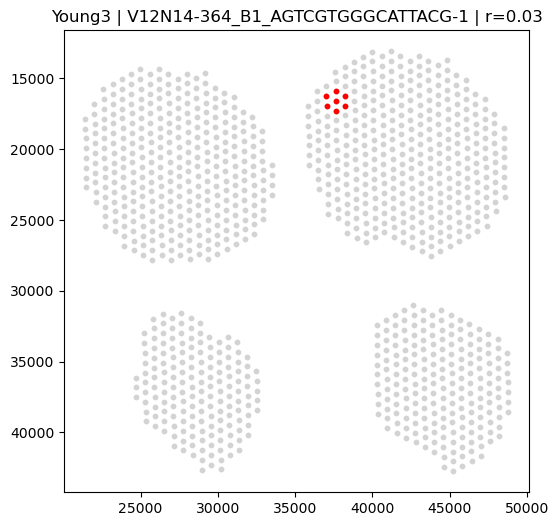

Young6 | Center: V12N14-363_A1_ACCGAAGAGTCTGGTT-1 | Radius: 1028.50 | Spots: 7


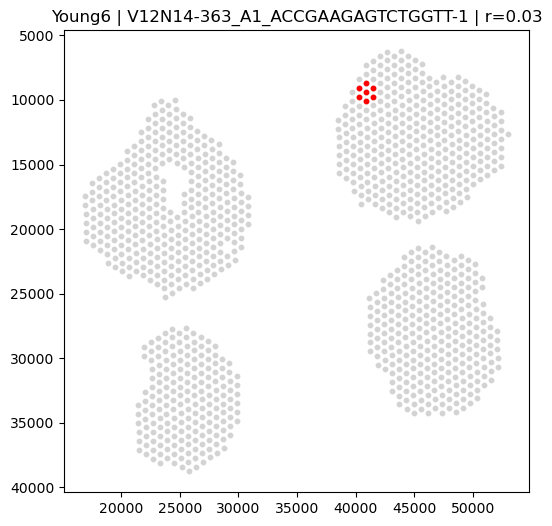

Aged6 | Center: V12N14-362_A1_CGACTTTGTATAGCCT-1 | Radius: 817.49 | Spots: 6


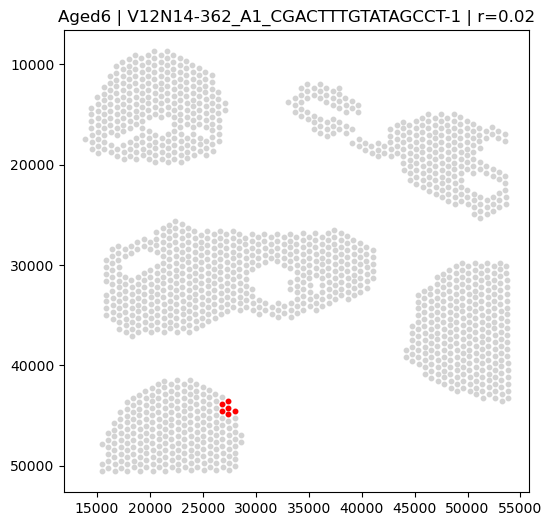

Aged5 | Center: V12N14-362_B1_TTGACTACCATATGGT-1 | Radius: 817.04 | Spots: 7


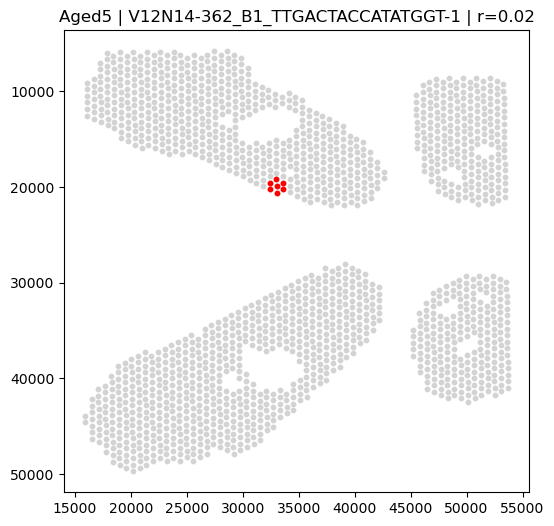

Young1 | Center: V12N14-364_D1_TTGTAAGGACCTAAGT-1 | Radius: 741.85 | Spots: 4


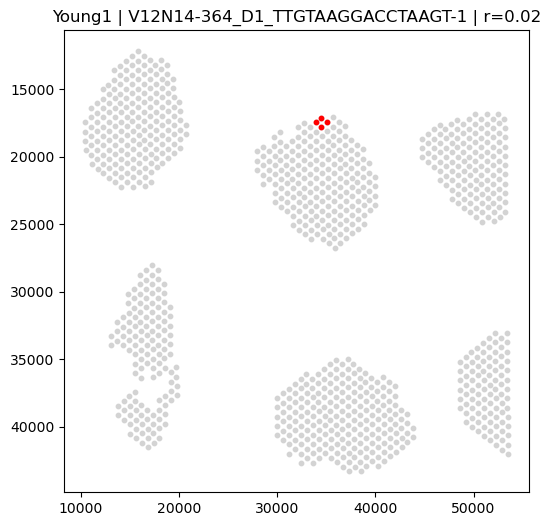

Young4 | Center: V12N14-364_A1_GACTACAAAGCGGTGG-1 | Radius: 995.99 | Spots: 7


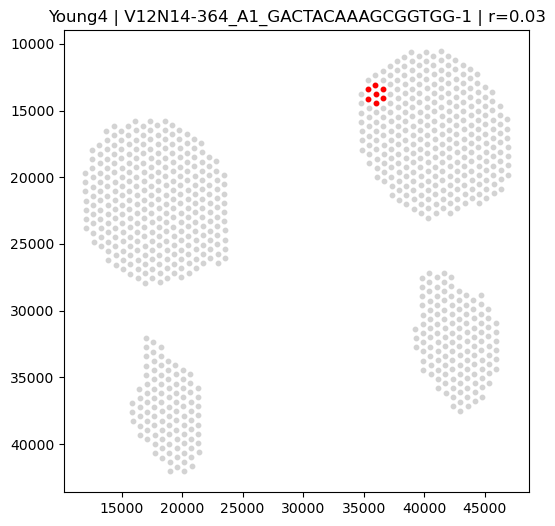

Aged7 | Center: V12M07-027_D1_ATTCCTCCGCCAGTGC-1 | Radius: 825.00 | Spots: 7


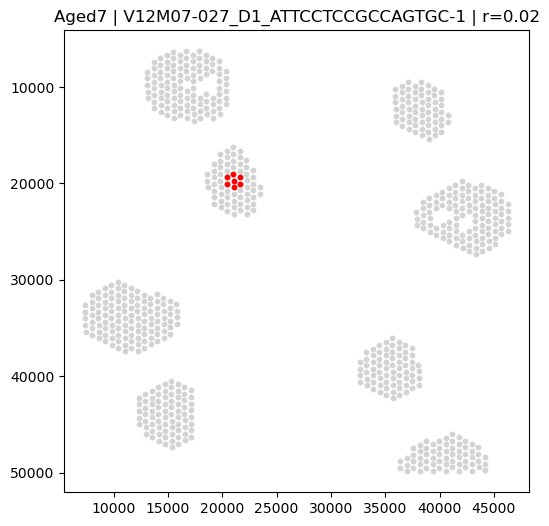

Aged10 | Center: V12M07-027_A1_AGAACCCAGCGTGACA-1 | Radius: 861.71 | Spots: 7


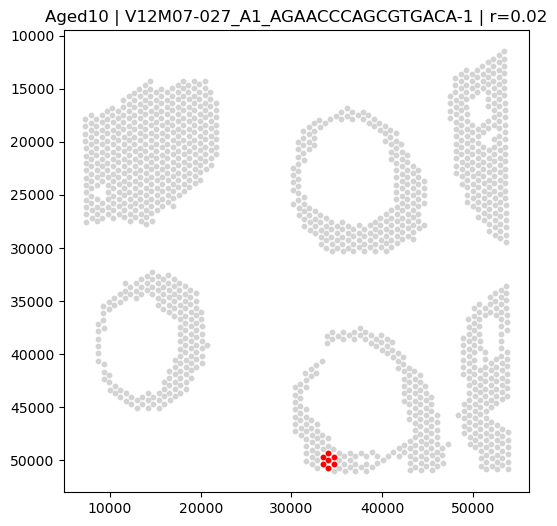

Young2 | Center: V12N14-364_C1_CATACGAACTAGCTGG-1 | Radius: 868.88 | Spots: 4


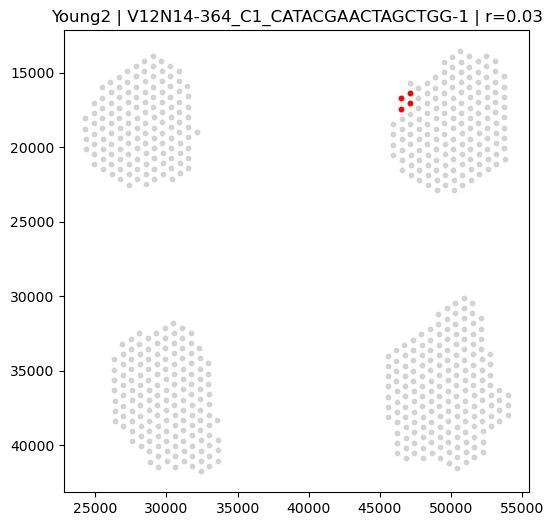

Young5 | Center: V12N14-363_B1_TATTAACCTGACCGCG-1 | Radius: 803.90 | Spots: 7


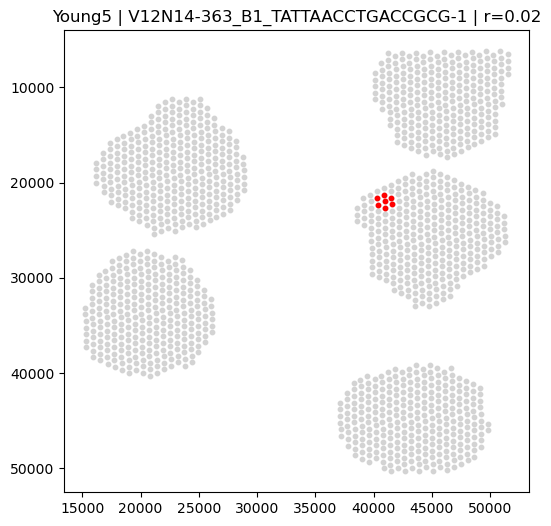

Aged9 | Center: V12M07-027_B1_ACAACAGCATGAGCTA-1 | Radius: 808.67 | Spots: 7


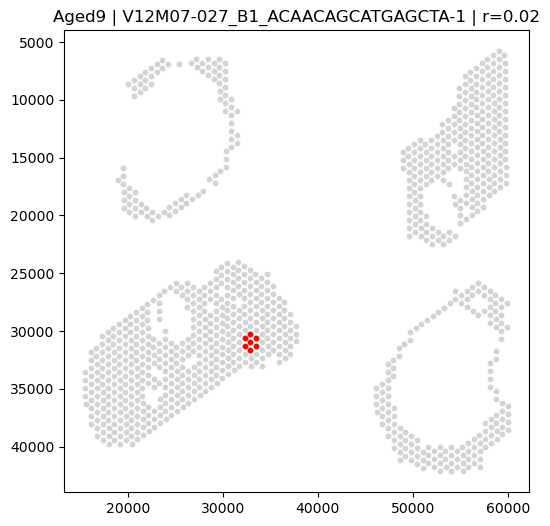

Aged8 | Center: V12M07-027_C1_ACAGGCTTGCCCGACT-1 | Radius: 841.20 | Spots: 7


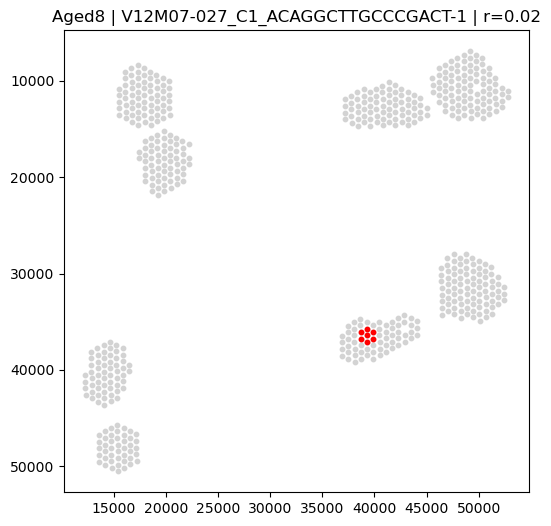

Aged3 | Center: V12N14-362_D1_ATCGCCAGTCAACATT-1 | Radius: 858.30 | Spots: 4


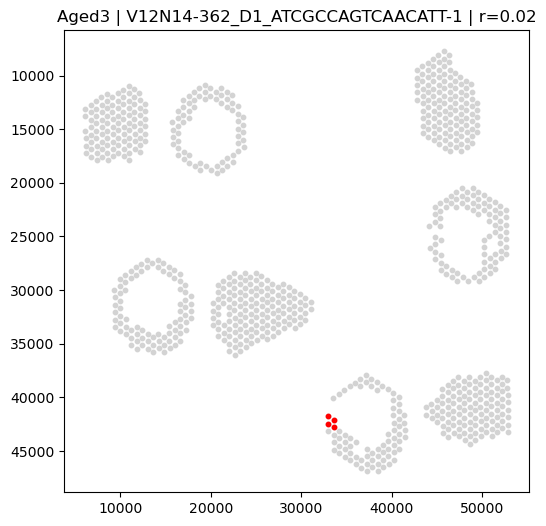

Aged2 | Center: V12N14-363_C1_GGAACGGCCTGCAGCC-1 | Radius: 944.46 | Spots: 7


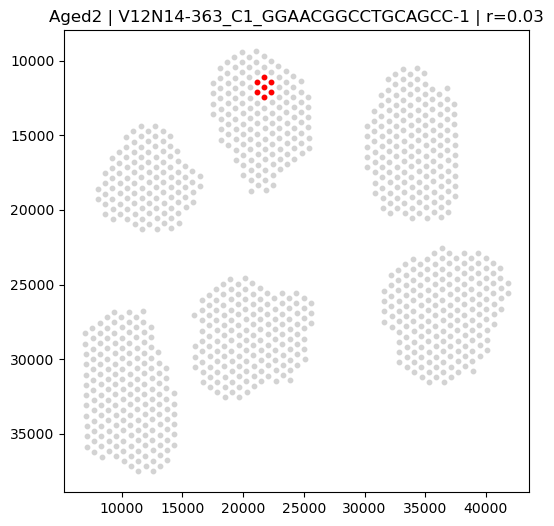

Aged4 | Center: V12N14-362_C1_CCTCCGACAATTCAAG-1 | Radius: 757.52 | Spots: 5


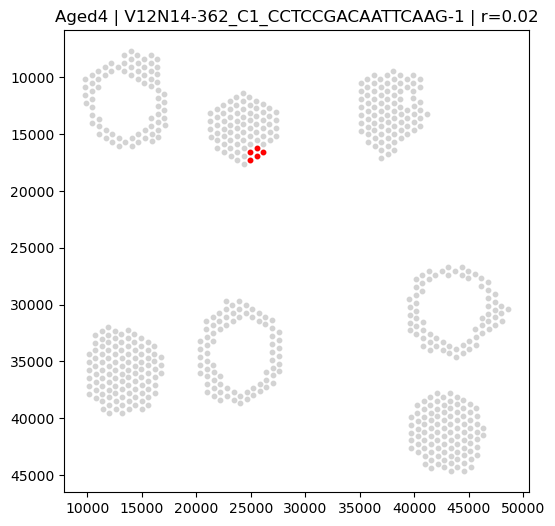

Aged1 | Center: V12N14-363_D1_TCTGACGGGCTAACCC-1 | Radius: 878.62 | Spots: 7


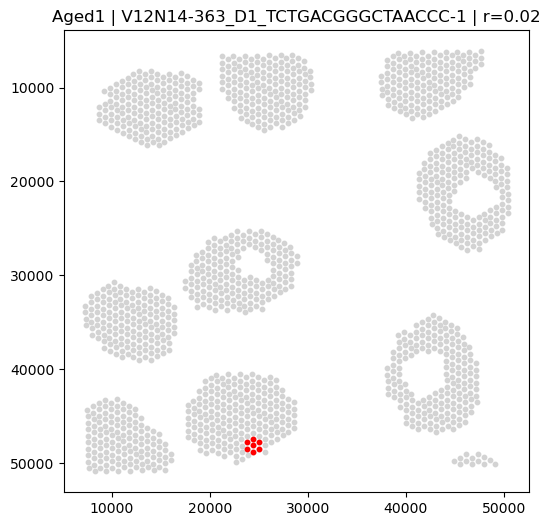

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def get_neighborhood(adata, center_spot, radius_ratio=0.02, spatial_key='spatial'):
    coords = adata.obsm[spatial_key]
    if not isinstance(coords, np.ndarray):
        coords = coords.to_numpy()
    center_idx = np.where(adata.obs.index == center_spot)[0][0]
    center_coord = coords[center_idx]
    coord_range = coords.max(axis=0) - coords.min(axis=0)
    radius = radius_ratio * np.mean(coord_range)
    distances = np.linalg.norm(coords - center_coord, axis=1)
    return adata[distances <= radius].copy(), radius

def plot_neighborhood_overlay(adata, adata_subset, spatial_key='spatial', title=None):
    all_coords = adata.obsm[spatial_key]
    sub_coords = adata_subset.obsm[spatial_key]
    plt.figure(figsize=(6,6))
    plt.scatter(all_coords[:,0], all_coords[:,1], s=10, c='lightgray')
    plt.scatter(sub_coords[:,0], sub_coords[:,1], s=10, c='red')
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.show()

special_groups = ["Young6", "Aged2", "Young4", "Young3", "Young2"]

groups = adata_vis.obs['group'].unique()

for g in groups:
    adata_g = adata_vis[adata_vis.obs['group'] == g].copy()
    coords = adata_g.obsm['spatial']

    center_idx = np.lexsort((coords[:,1], coords[:,0]))[len(coords)//2]
    center_spot = adata_g.obs.index[center_idx]

    radius_ratio = 0.03 if g in special_groups else 0.02
    #radius_ratio = 0.05 if g in special_groups else 0.04
    subset, radius_used = get_neighborhood(
        adata_g,
        center_spot,
        radius_ratio=radius_ratio
    )

    print(f"{g} | Center: {center_spot} | Radius: {radius_used:.2f} | Spots: {subset.n_obs}")

    plot_neighborhood_overlay(
        adata_g,
        subset,
        title=f"{g} | {center_spot} | r={radius_ratio}"
    )

/tmp/ipykernel_3633742/2005168328.py:59: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_p, p_p = pearsonr(x_combined, y_tgfb)
/tmp/ipykernel_3633742/2005168328.py:60: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_s, p_s = spearmanr(x_combined, y_tgfb)


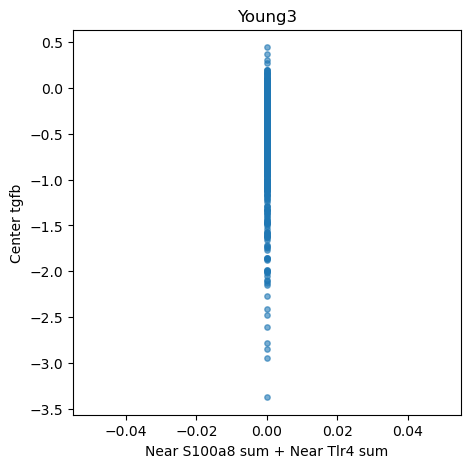

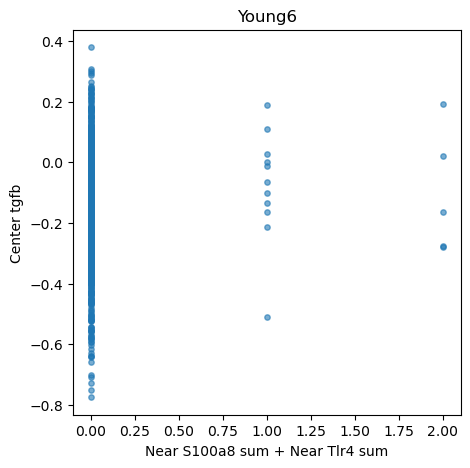

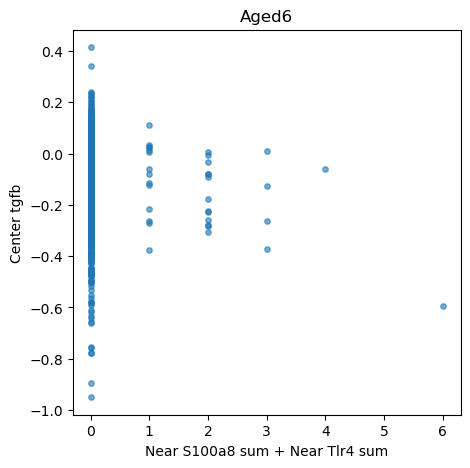

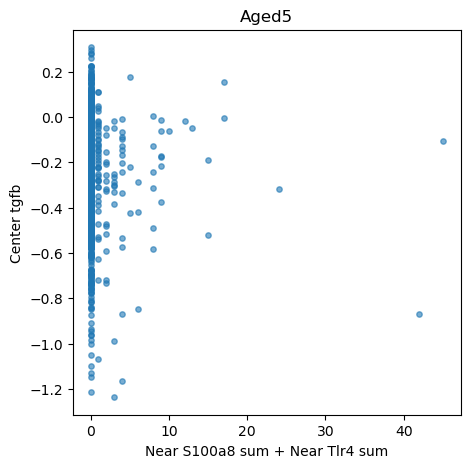

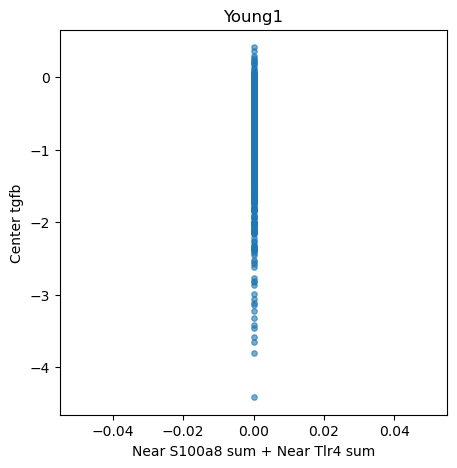

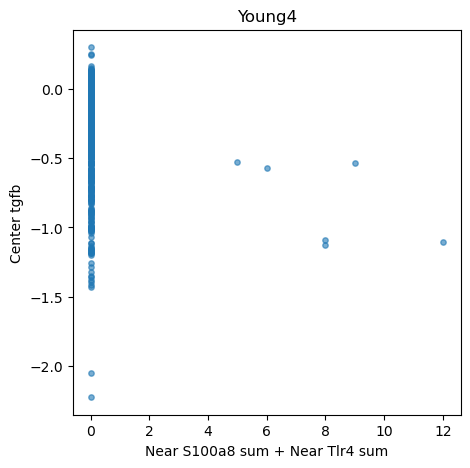

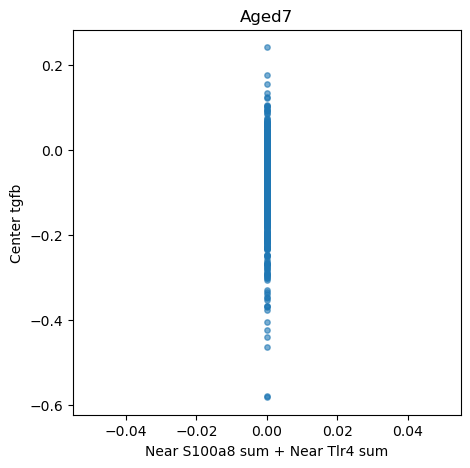

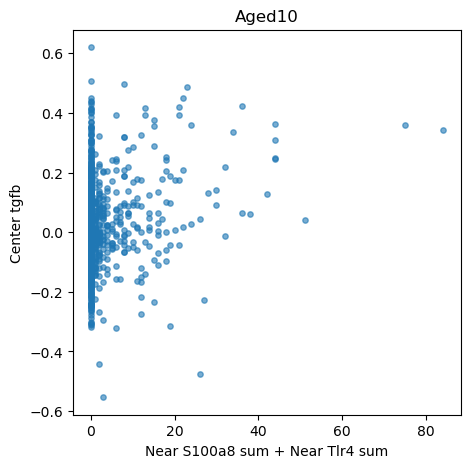

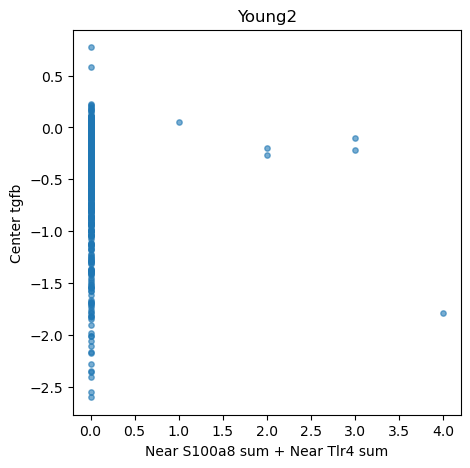

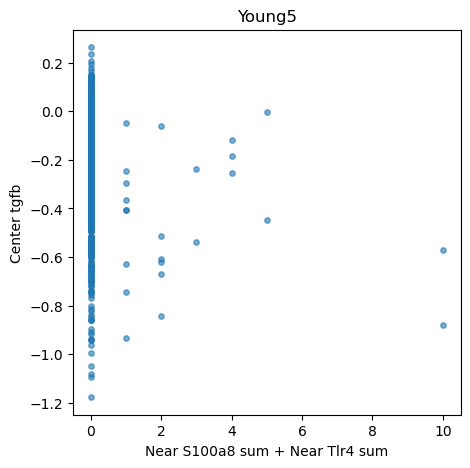

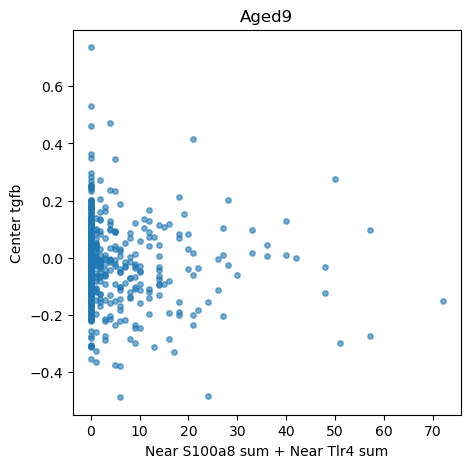

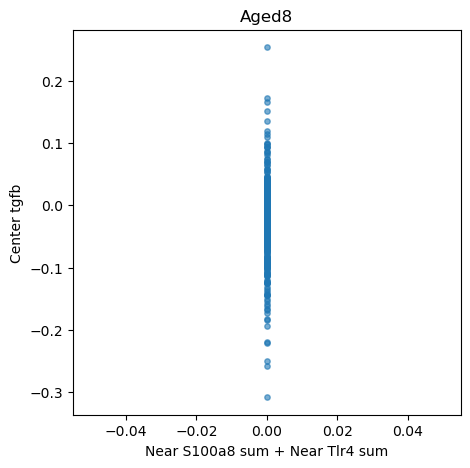

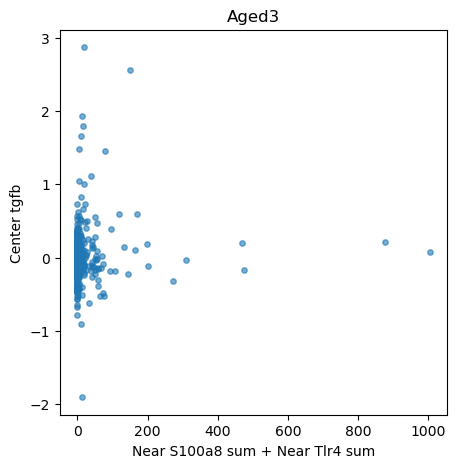

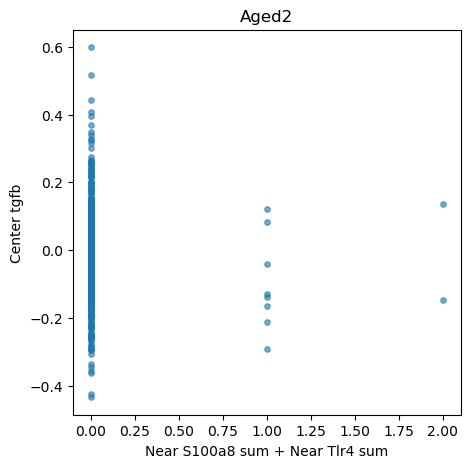

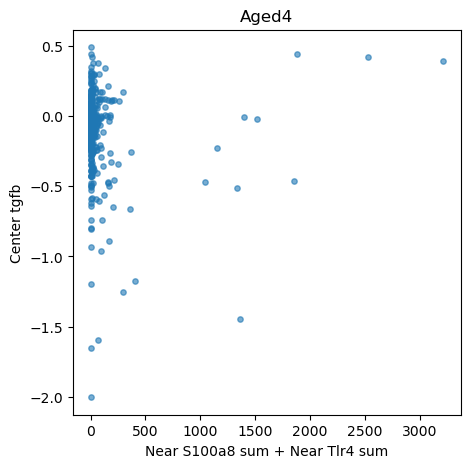

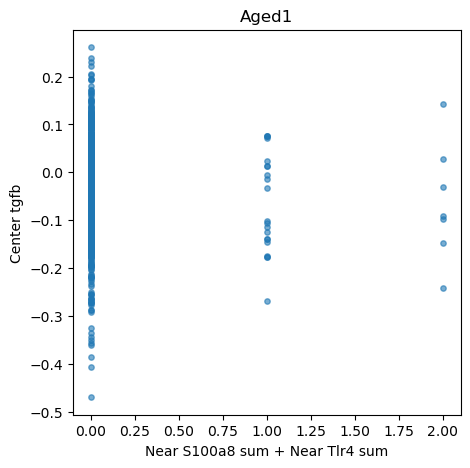

Group	Pearson_r	Pearson_p	Spearman_r	Spearman_p
Young3	nan	nan	nan	nan
Young6	0.009	7.624e-01	0.008	7.946e-01
Aged6	-0.084	9.457e-04	-0.053	3.835e-02
Aged5	-0.067	4.608e-03	-0.090	1.489e-04
Young1	nan	nan	nan	nan
Young4	-0.158	4.233e-06	-0.119	5.488e-04
Aged7	nan	nan	nan	nan
Aged10	0.207	3.333e-14	0.106	1.114e-04
Young2	-0.025	5.389e-01	0.024	5.587e-01
Young5	-0.148	9.096e-09	-0.139	6.117e-08
Aged9	-0.093	3.661e-03	-0.120	1.604e-04
Aged8	nan	nan	nan	nan
Aged3	0.075	3.059e-02	0.087	1.286e-02
Aged2	-0.048	1.419e-01	-0.055	9.412e-02
Aged4	-0.034	4.002e-01	-0.063	1.216e-01
Aged1	-0.053	4.029e-02	-0.046	7.226e-02


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy import sparse

def get_neighborhood(adata, center_idx, radius_ratio=0.02, spatial_key='spatial'):
    coords = adata.obsm[spatial_key]
    if not isinstance(coords, np.ndarray):
        coords = coords.to_numpy()
    center_coord = coords[center_idx]
    coord_range = coords.max(axis=0) - coords.min(axis=0)
    radius = radius_ratio * np.mean(coord_range)
    distances = np.linalg.norm(coords - center_coord, axis=1)
    return np.where(distances <= radius)[0]

special_groups = ["Young6", "Aged2", "Young4", "Young3", "Young2"]

idx_s100a8 = np.where(adata_vis.var_names == "S100a8")[0][0]
idx_tlr4   = np.where(adata_vis.var_names == "Tlr4")[0][0]

groups = adata_vis.obs['group'].unique()
results = []

for g in groups:
    adata_g = adata_vis[adata_vis.obs['group'] == g].copy()
    coords = adata_g.obsm['spatial']
    order = np.lexsort((coords[:,1], coords[:,0]))
    radius_ratio = 0.03 if g in special_groups else 0.02

    x_combined = []
    y_tgfb = []

    for idx in order:
        if adata_g.obs.iloc[idx]['module2'] == 0:
            continue

        neigh_idx = get_neighborhood(adata_g, idx, radius_ratio)

        # 주변 S100a8 합
        near_s100a8_expr = adata_g.X[neigh_idx, idx_s100a8]
        if sparse.issparse(near_s100a8_expr):
            near_s100a8 = near_s100a8_expr.sum()
        else:
            near_s100a8 = near_s100a8_expr.sum()

        # 주변 Tlr4 합
        near_tlr4_expr = adata_g.X[neigh_idx, idx_tlr4]
        if sparse.issparse(near_tlr4_expr):
            near_tlr4 = near_tlr4_expr.sum()
        else:
            near_tlr4 = near_tlr4_expr.sum()

        x_combined.append(near_s100a8 * near_tlr4)
        y_tgfb.append(float(adata_g.obs.iloc[idx]['tgfb']))

    x_combined = np.asarray(x_combined, dtype=float)
    y_tgfb = np.asarray(y_tgfb, dtype=float)

    r_p, p_p = pearsonr(x_combined, y_tgfb)
    r_s, p_s = spearmanr(x_combined, y_tgfb)

    results.append((g, r_p, p_p, r_s, p_s))

    plt.figure(figsize=(5,5))
    plt.scatter(x_combined, y_tgfb, s=15, alpha=0.6)
    plt.xlabel("Near S100a8 sum + Near Tlr4 sum")
    plt.ylabel("Center tgfb")
    plt.title(g)
    plt.show()

print("Group\tPearson_r\tPearson_p\tSpearman_r\tSpearman_p")
for g, r_p, p_p, r_s, p_s in results:
    print(f"{g}\t{r_p:.3f}\t{p_p:.3e}\t{r_s:.3f}\t{p_s:.3e}")


# AUCell

In [102]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

adata_vis = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad")
adata_vis.layers['counts'] = adata_vis.X
sc.pp.normalize_total(adata_vis, inplace=True)
sc.pp.log1p(adata_vis)

geneset = ['Tgfb1', 'Acvr1', 'Rhoa', 'Smurf2', 'Smurf1', 'Hipk2', 'Tgfbr1', 'Ppp1ca', 'Cdk9', 'Ski', 'Rab31', 'Apc', 'Bmp2', 'Ncor2', 'Id1', 'Id3', 'Id2', 'Bmpr1a', 'Bcar3', 'Bmpr2', 'Serpine1', 'N/A', 'Ppp1r15a', 'Arid4b', 'Cdh1', 'Map3k7', 'Skil', 'Sptbn1', 'Smad3', 'Wwtr1', 'Tgif1', 'Lefty1', 'Nog', 'Ifngr2', 'Smad1', 'Klf10', 'Smad7', 'Smad6', 'Ppm1a', 'Fkbp1a', 'Tjp1', 'Xiap', 'Eng', 'Trim33', 'Cdkn1c', 'Hdac1', 'Furin', 'Ctnnb1', 'Slc20a1', 'Thbs1', 'Ltbp2', 'Fnta', 'Pmepa1', 'Junb']
sc.tl.score_genes(adata_vis, geneset , score_name='tgfb',use_raw=False)

In [103]:
import glob

auc_dir = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/AUCell"
csv_files = glob.glob(f"{auc_dir}/*_all_cells_all_genesets_AUC_transposed.csv")

auc_list = []

for f in csv_files:
    df = pd.read_csv(f, index_col=0)
    auc_list.append(df)

auc_all = pd.concat(auc_list, axis=0)

tf_auc = auc_all.loc[
    auc_all.index.intersection(adata_vis.obs.index),
    "TF"]

adata_vis.obs["TF_AUC"] = tf_auc.reindex(adata_vis.obs.index)

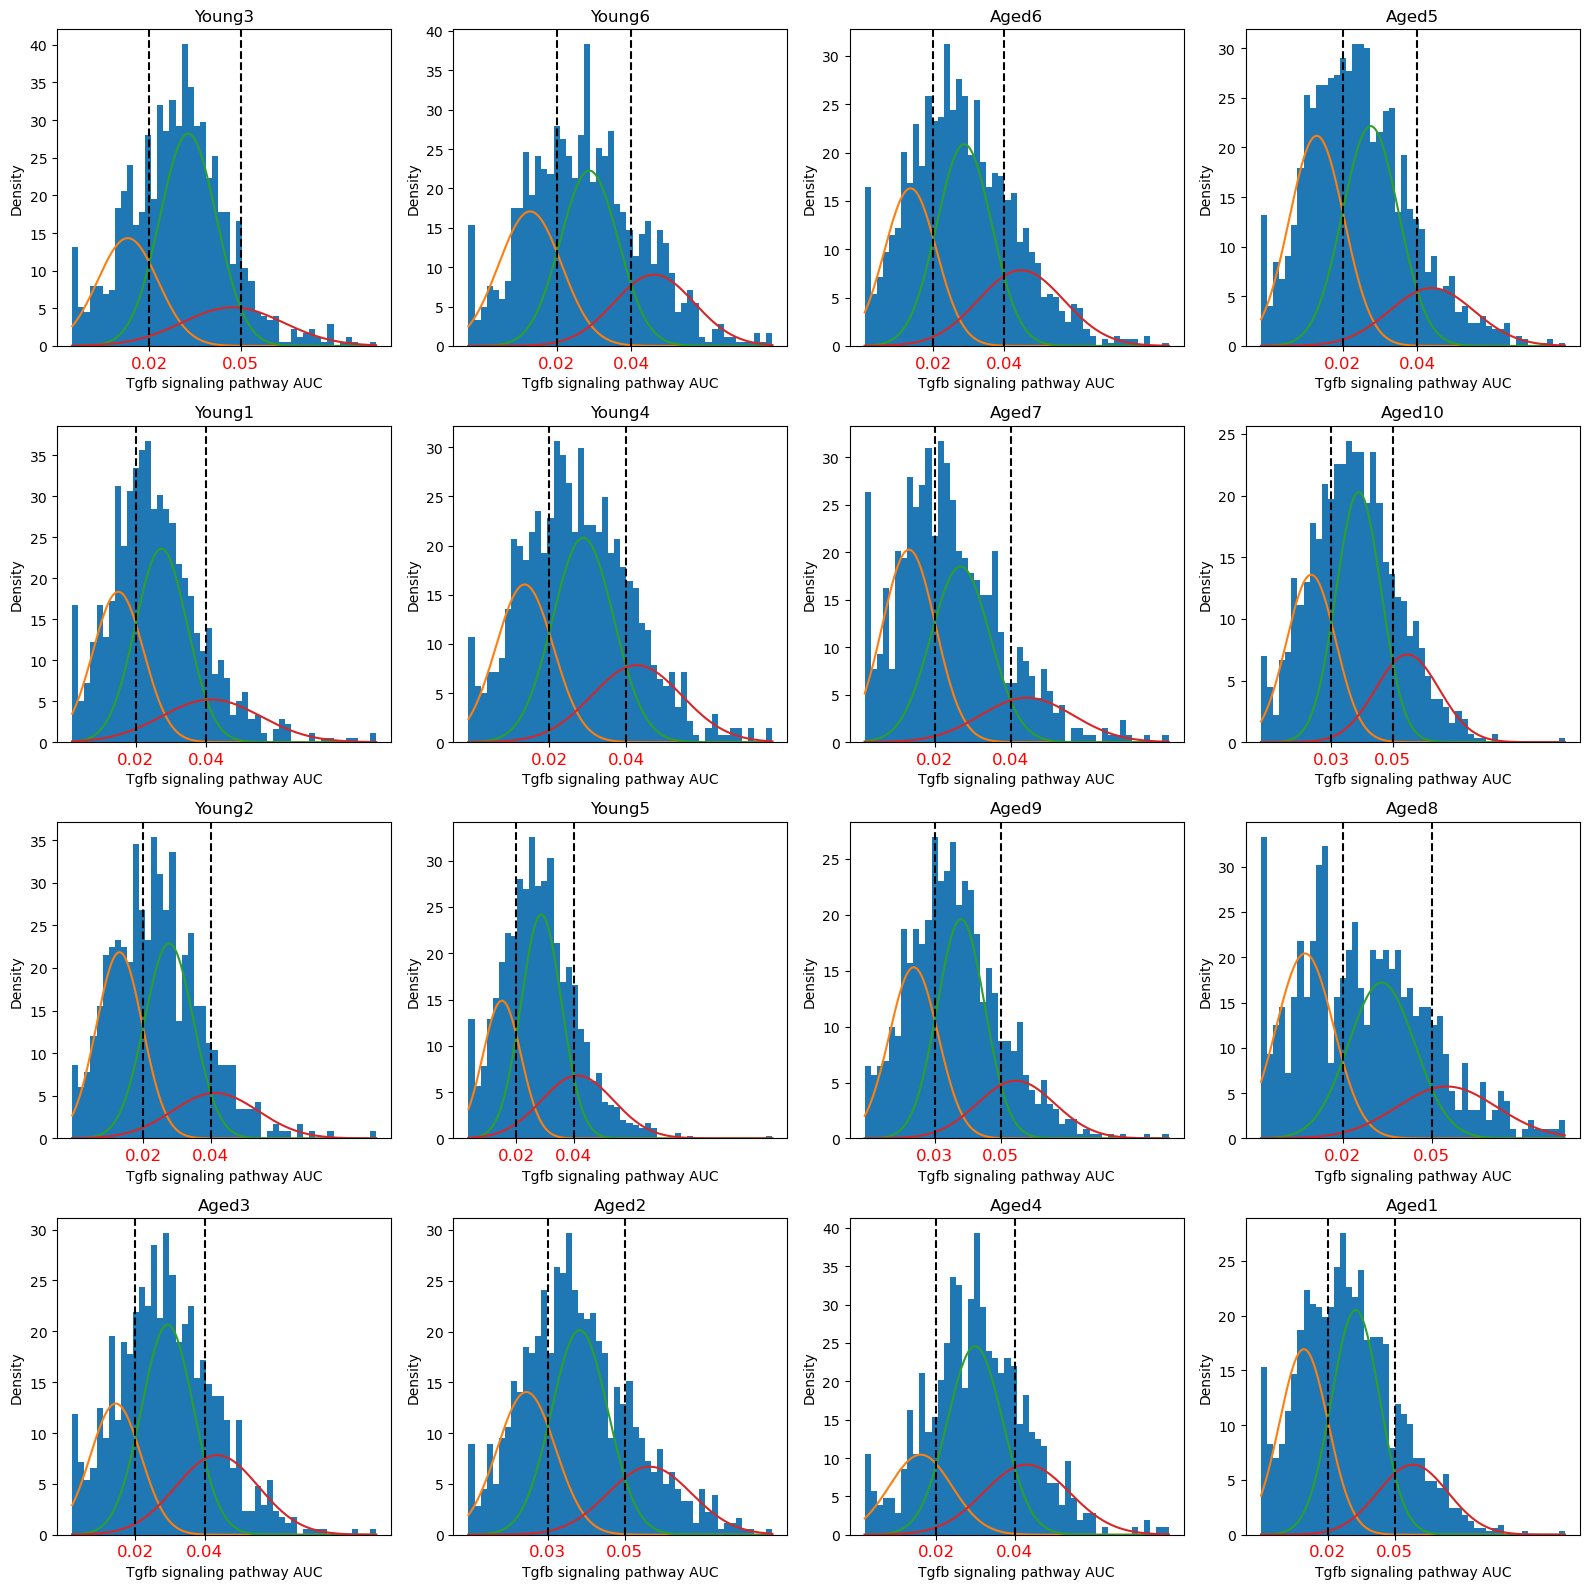

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
import math

bins = 50

def robust_cutoff_mid_anchored(xx, pdf1, pdf2, m_mid, side, gmm, comp1, comp2):
    diff = pdf1 - pdf2
    idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]

    xs = []
    densities = []

    for i in idx:
        xi = xx[i] - diff[i] * (xx[i+1] - xx[i]) / (diff[i+1] - diff[i])

        if side == "left" and xi < m_mid:
            xs.append(xi)
            densities.append(pdf1[i] + pdf2[i])

        if side == "right" and xi > m_mid:
            xs.append(xi)
            densities.append(pdf1[i] + pdf2[i])

    if len(xs) > 0:
        return xs[np.argmax(densities)]

    post = gmm.predict_proba(xx.reshape(-1, 1))
    diff_post = post[:, comp1] - post[:, comp2]
    idx2 = np.where(np.sign(diff_post[:-1]) != np.sign(diff_post[1:]))[0]

    for i in idx2:
        xi = xx[i]
        if side == "left" and xi < m_mid:
            return xi
        if side == "right" and xi > m_mid:
            return xi

    if side == "left":
        return np.percentile(xx[xx < m_mid], 90)

    return np.percentile(xx[xx > m_mid], 10)


groups = list(adata_vis.obs["group"].unique())
n = len(groups)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, g in zip(axes, groups):

    x = (
        adata_vis.obs
        .loc[adata_vis.obs["group"] == g, "TF_AUC"]
        .dropna()
        .values
        .reshape(-1, 1)
    )

    if x.shape[0] < 50:
        ax.set_title(f"{g} (n<50)")
        ax.axis("off")
        continue

    gmm = GaussianMixture(n_components=3, random_state=0)
    gmm.fit(x)

    xx = np.linspace(x.min(), x.max(), 2000)

    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_

    order = np.argsort(means)
    means = means[order]
    stds = stds[order]
    weights = weights[order]

    pdfs = np.array([
        weights[i] * norm.pdf(xx, means[i], stds[i])
        for i in range(3)
    ])

    m_mid = means[1]

    cut1 = robust_cutoff_mid_anchored(
        xx, pdfs[0], pdfs[1],
        m_mid, "left",
        gmm, 0, 1
    )

    cut2 = robust_cutoff_mid_anchored(
        xx, pdfs[1], pdfs[2],
        m_mid, "right",
        gmm, 1, 2
    )

    ax.hist(x.flatten(), bins=bins, density=True)

    for i in range(3):
        ax.plot(xx, pdfs[i])

    ax.axvline(cut1,color="black", linestyle="--")
    ax.axvline(cut2,color="black", linestyle="--")

    ax.set_xticks([cut1, cut2])
    ax.set_xticklabels([f"{cut1:.2f}", f"{cut2:.2f}"], color="red",fontsize=12)

    ax.set_title(g)
    ax.set_xlabel("Tgfb signaling pathway AUC")
    ax.set_ylabel("Density")

for ax in axes[len(groups):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [105]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

def robust_cutoff_mid_anchored(xx, pdf1, pdf2, m_mid, side, gmm, comp1, comp2):
    diff = pdf1 - pdf2
    idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]

    xs = []
    densities = []

    for i in idx:
        xi = xx[i] - diff[i] * (xx[i+1] - xx[i]) / (diff[i+1] - diff[i])
        if side == "left" and xi < m_mid:
            xs.append(xi)
            densities.append(pdf1[i] + pdf2[i])
        if side == "right" and xi > m_mid:
            xs.append(xi)
            densities.append(pdf1[i] + pdf2[i])

    if len(xs) > 0:
        return xs[np.argmax(densities)]

    post = gmm.predict_proba(xx.reshape(-1, 1))
    diff_post = post[:, comp1] - post[:, comp2]
    idx2 = np.where(np.sign(diff_post[:-1]) != np.sign(diff_post[1:]))[0]

    for i in idx2:
        xi = xx[i]
        if side == "left" and xi < m_mid:
            return xi
        if side == "right" and xi > m_mid:
            return xi

    if side == "left":
        return np.percentile(xx[xx < m_mid], 90)

    return np.percentile(xx[xx > m_mid], 10)


rows = []

for g in adata_vis.obs["group"].unique():

    x = (
        adata_vis.obs
        .loc[adata_vis.obs["group"] == g, "TF_AUC"]
        .dropna()
        .values
        .reshape(-1, 1)
    )

    n = x.shape[0]

    if n < 50:
        rows.append([g, np.nan, np.nan, n])
        continue

    gmm = GaussianMixture(n_components=3, random_state=0)
    gmm.fit(x)

    xx = np.linspace(x.min(), x.max(), 2000)

    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_

    order = np.argsort(means)
    means = means[order]
    stds = stds[order]
    weights = weights[order]

    pdfs = np.array([
        weights[i] * norm.pdf(xx, means[i], stds[i])
        for i in range(3)
    ])

    m_mid = means[1]

    cut1 = robust_cutoff_mid_anchored(xx, pdfs[0], pdfs[1], m_mid, "left", gmm, 0, 1)
    cut2 = robust_cutoff_mid_anchored(xx, pdfs[1], pdfs[2], m_mid, "right", gmm, 1, 2)

    rows.append([g, cut1, cut2, n])


cutoff_df = pd.DataFrame(
    rows,
    columns=["group", "cutoff_low_mid", "cutoff_mid_high", "n_obs"]
)

print(cutoff_df)

     group  cutoff_low_mid  cutoff_mid_high  n_obs
0   Young3        0.020681         0.045081   1074
1   Young6        0.022852         0.042077   1165
2    Aged6        0.020589         0.041783   1532
3    Aged5        0.022488         0.043063   1771
4   Young1        0.018996         0.040165    988
5   Young4        0.022211         0.043508    838
6    Aged7        0.021446         0.044653    695
7   Aged10        0.027565         0.051702   1322
8   Young2        0.021837         0.042783    618
9   Young5        0.018709         0.041216   1496
10   Aged9        0.026880         0.052355    985
11   Aged8        0.022577         0.047266    572
12   Aged3        0.021251         0.044582    824
13   Aged2        0.025142         0.049502    928
14   Aged4        0.020463         0.042816    601
15   Aged1        0.023522         0.047132   1525


In [106]:
import numpy as np

adata_vis.obs["AUCell_group"] = np.nan

cutoff_map = (
    cutoff_df
    .set_index("group")[["cutoff_low_mid", "cutoff_mid_high"]]
    .to_dict(orient="index"))

for g, idx in adata_vis.obs.groupby("group").groups.items():

    if g not in cutoff_map:
        continue
    cut1 = cutoff_map[g]["cutoff_low_mid"]
    cut2 = cutoff_map[g]["cutoff_mid_high"]
    if np.isnan(cut1) or np.isnan(cut2):
        continue

    vals = adata_vis.obs.loc[idx, "TF_AUC"]
    adata_vis.obs.loc[idx, "AUCell_group"] = np.where(
        vals < cut1, "Low",
        np.where(vals < cut2, "Medium", "High")    )

/tmp/ipykernel_3633742/1914621852.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for g, idx in adata_vis.obs.groupby("group").groups.items():
/tmp/ipykernel_3633742/1914621852.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Medium' 'Medium' 'Low' ... 'Medium' 'Medium' 'Medium']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata_vis.obs.loc[idx, "AUCell_group"] = np.where(


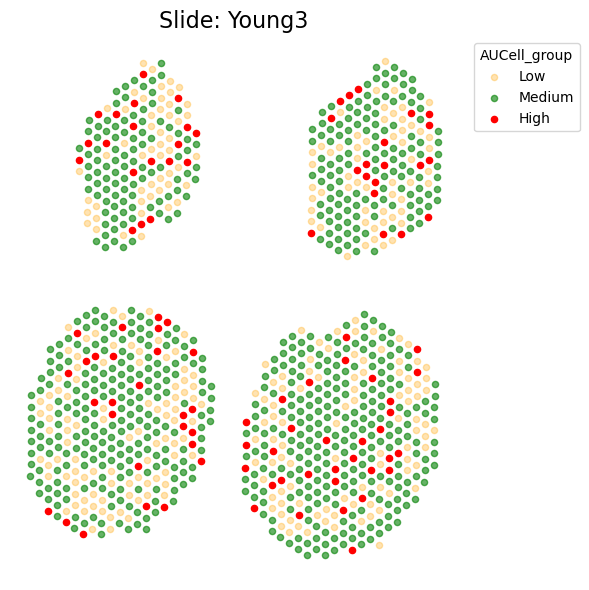

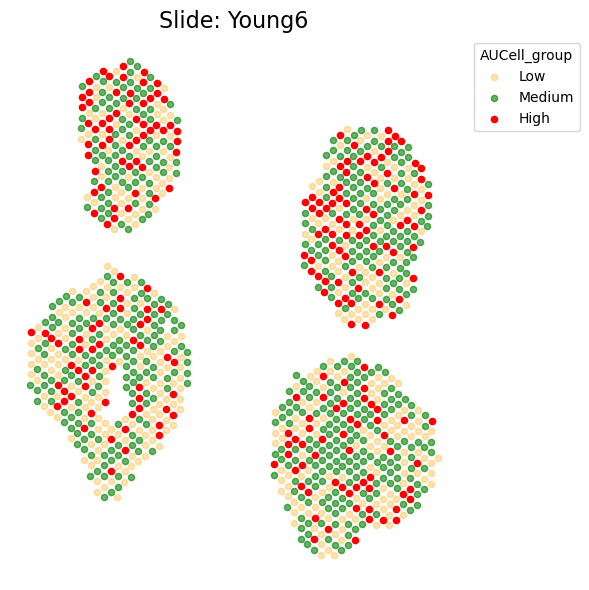

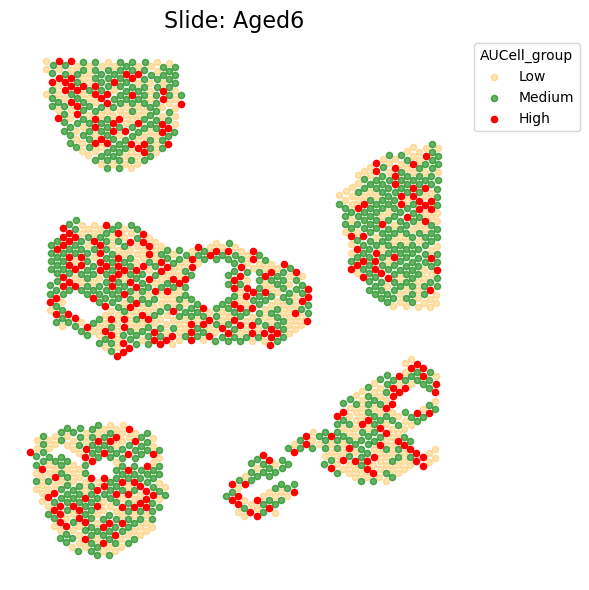

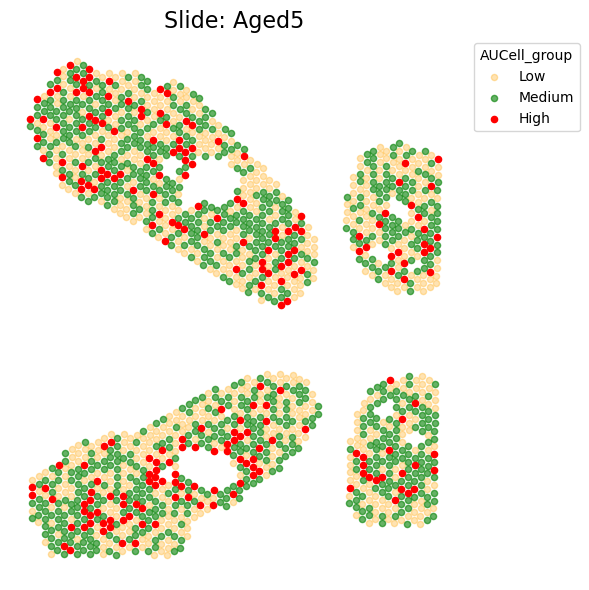

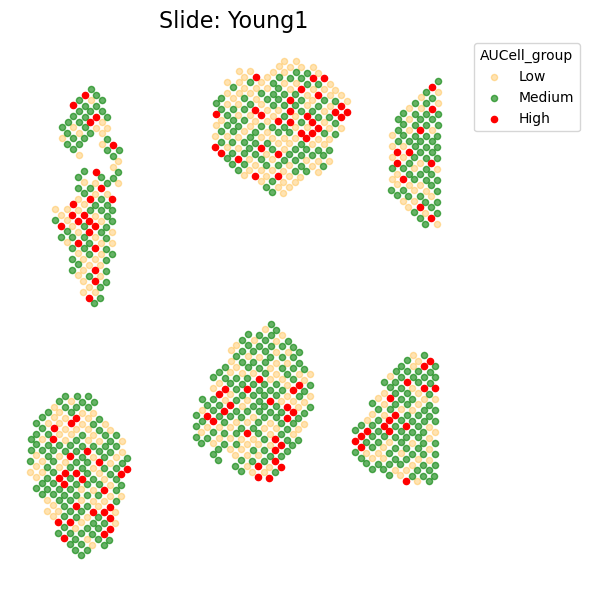

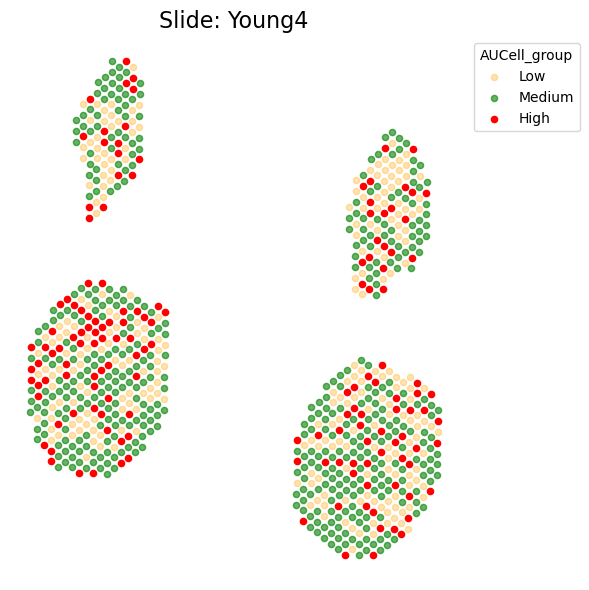

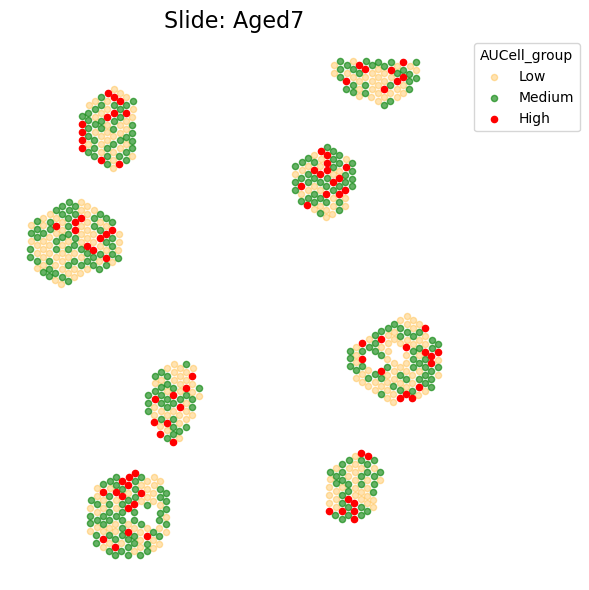

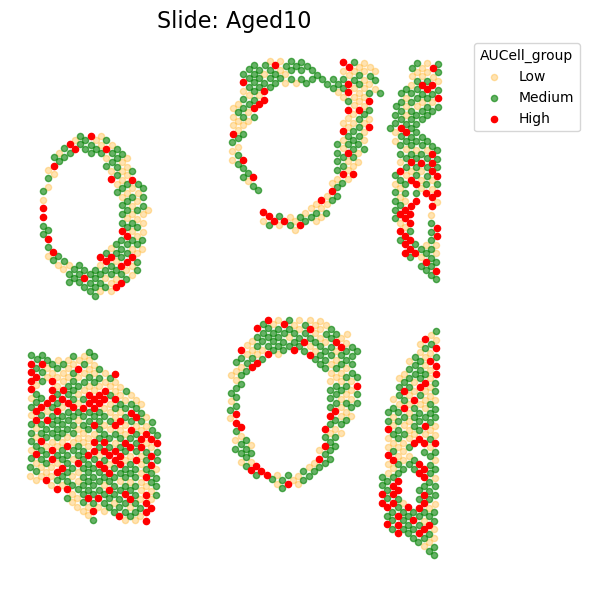

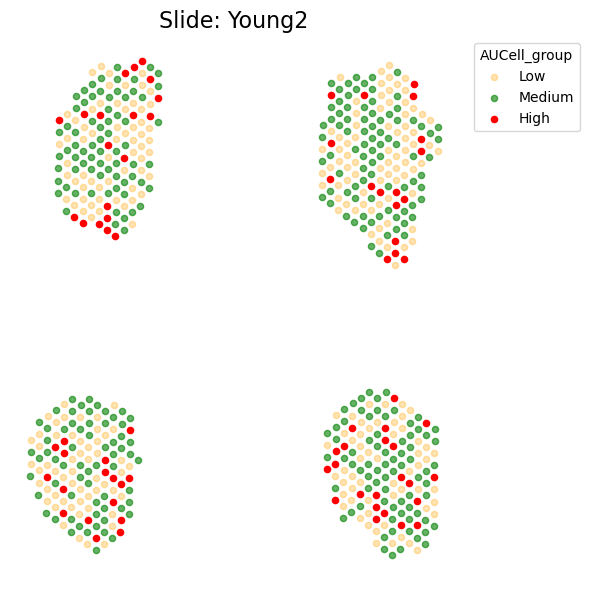

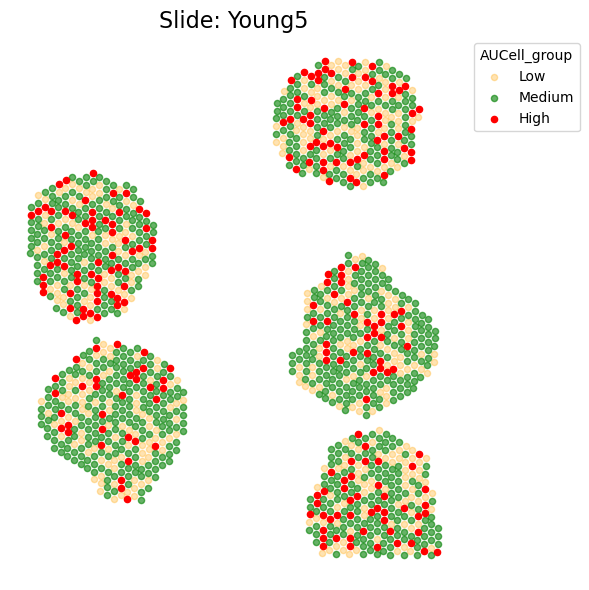

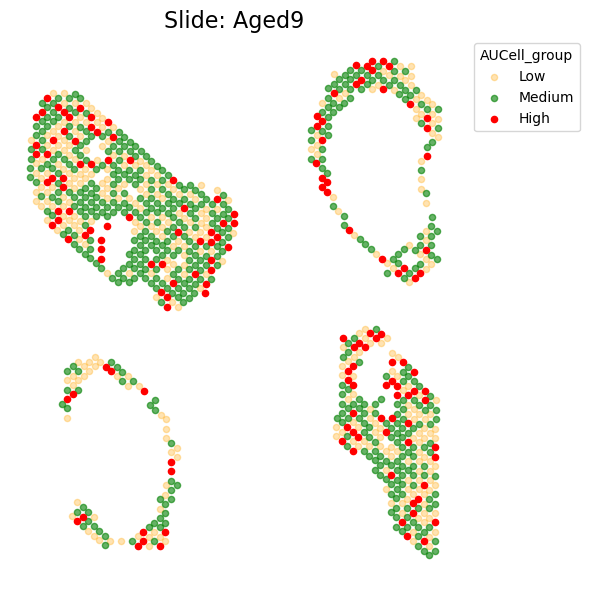

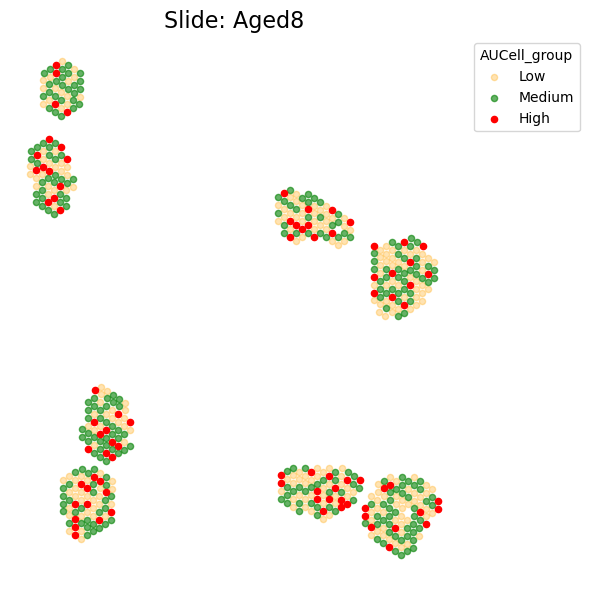

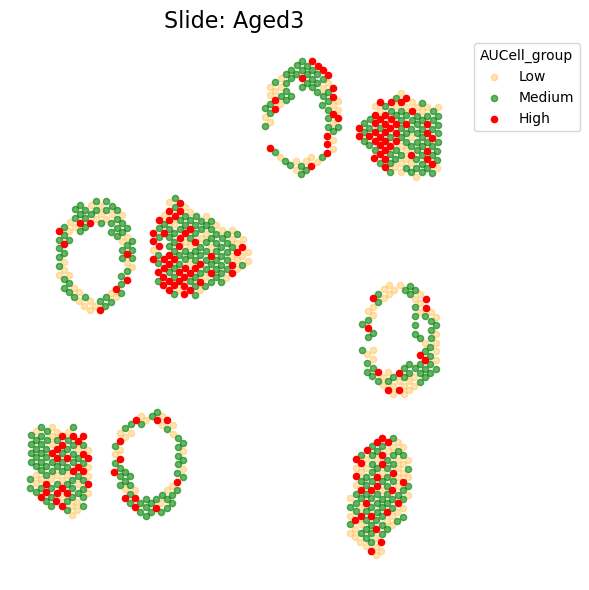

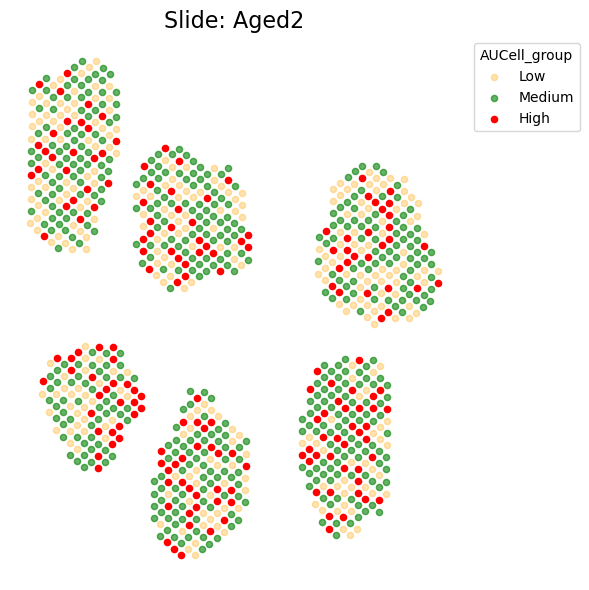

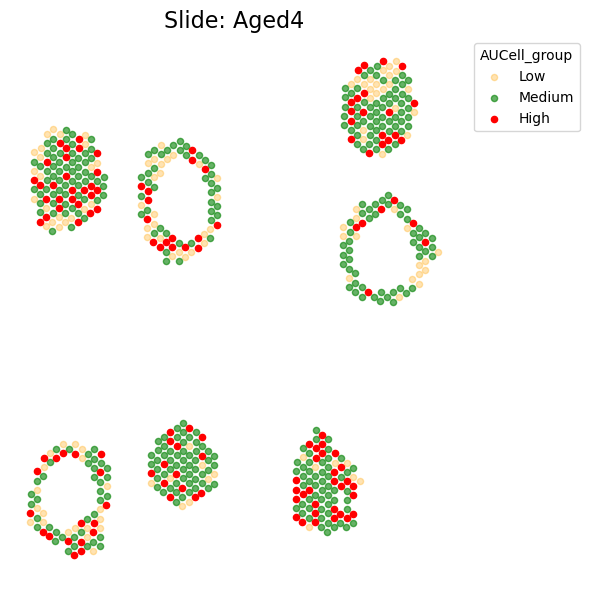

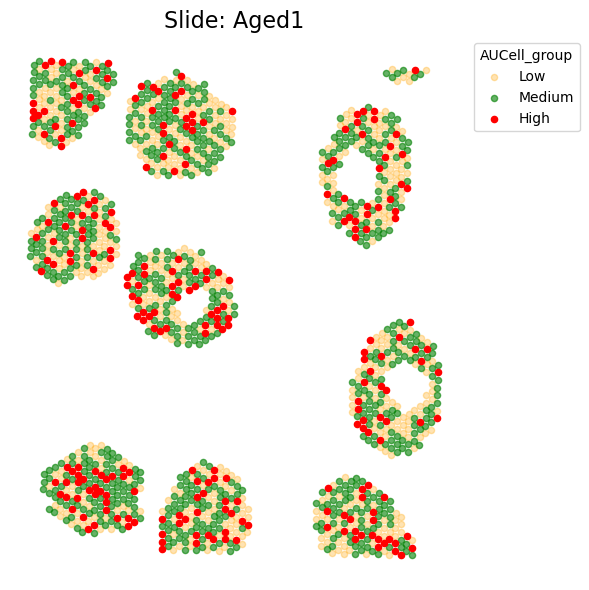

In [107]:
import matplotlib.pyplot as plt

colors_map = {"Low": "orange", "Medium": "green", "High": "red"}
alpha_map = {"Low": 0.3, "Medium": 0.6, "High": 1.0}

groups = adata_vis.obs['group'].unique()

for g in groups:
    ad = adata_vis[adata_vis.obs['group'] == g]
    coords = ad.obsm['spatial']
    auc = ad.obs['AUCell_group']
    
    plt.figure(figsize=(6,6))
    for grp in colors_map.keys():
        mask = auc == grp
        plt.scatter(coords[mask, 0], coords[mask, 1], 
                    c=colors_map[grp], alpha=alpha_map[grp], s=20, label=grp)
    
    plt.title(f"Slide: {g}", fontsize=16)
    plt.axis('off')
    
    plt.legend(title="AUCell_group", loc='upper left', bbox_to_anchor=(1.02, 1))
    
    plt.tight_layout()
    plt.show()

In [108]:
import numpy as np

def get_neighborhood_indices(adata, center_idx, radius_ratio=0.02, spatial_key="spatial"):
    coords = adata.obsm[spatial_key]
    if not isinstance(coords, np.ndarray):
        coords = coords.to_numpy()

    center_coord = coords[center_idx]
    coord_range = coords.max(axis=0) - coords.min(axis=0)
    radius = radius_ratio * np.mean(coord_range)

    distances = np.linalg.norm(coords - center_coord, axis=1)
    neigh_idx = np.where(distances <= radius)[0]

    return neigh_idx


special_keys = ["Young6", "Aged2", "Young4", "Young3", "Young2"]

adata_vis.obs["nearspot"] = np.nan

idx_tlr4 = np.where(adata_vis.var_names == "Tlr4")[0][0]
idx_s100a8 = np.where(adata_vis.var_names == "S100a8")[0][0]

X = adata_vis.X

for i, g in enumerate(adata_vis.obs["group"]):
    radius_ratio = 0.03 if any(k in g for k in special_keys) else 0.02

    neigh_idx = get_neighborhood_indices(
        adata_vis,
        center_idx=i,
        radius_ratio=radius_ratio
    )

    if len(neigh_idx) <= 1:
        continue

    neigh_idx = neigh_idx[neigh_idx != i]

    if hasattr(X, "toarray"):
        s100a8_vals = X[neigh_idx, idx_s100a8].toarray().flatten()
        tlr4_vals   = X[neigh_idx, idx_tlr4].toarray().flatten()
    else:
        s100a8_vals = X[neigh_idx, idx_s100a8]
        tlr4_vals   = X[neigh_idx, idx_tlr4]

    adata_vis.obs.iloc[i, adata_vis.obs.columns.get_loc("nearspot")] = (
        np.sum(s100a8_vals) * np.sum(tlr4_vals)
    )

/tmp/ipykernel_3633742/3419911723.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_3633742/3419911723.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_3633742/3419911723.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_3633742/3419911723.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_3633742/3419911723.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot

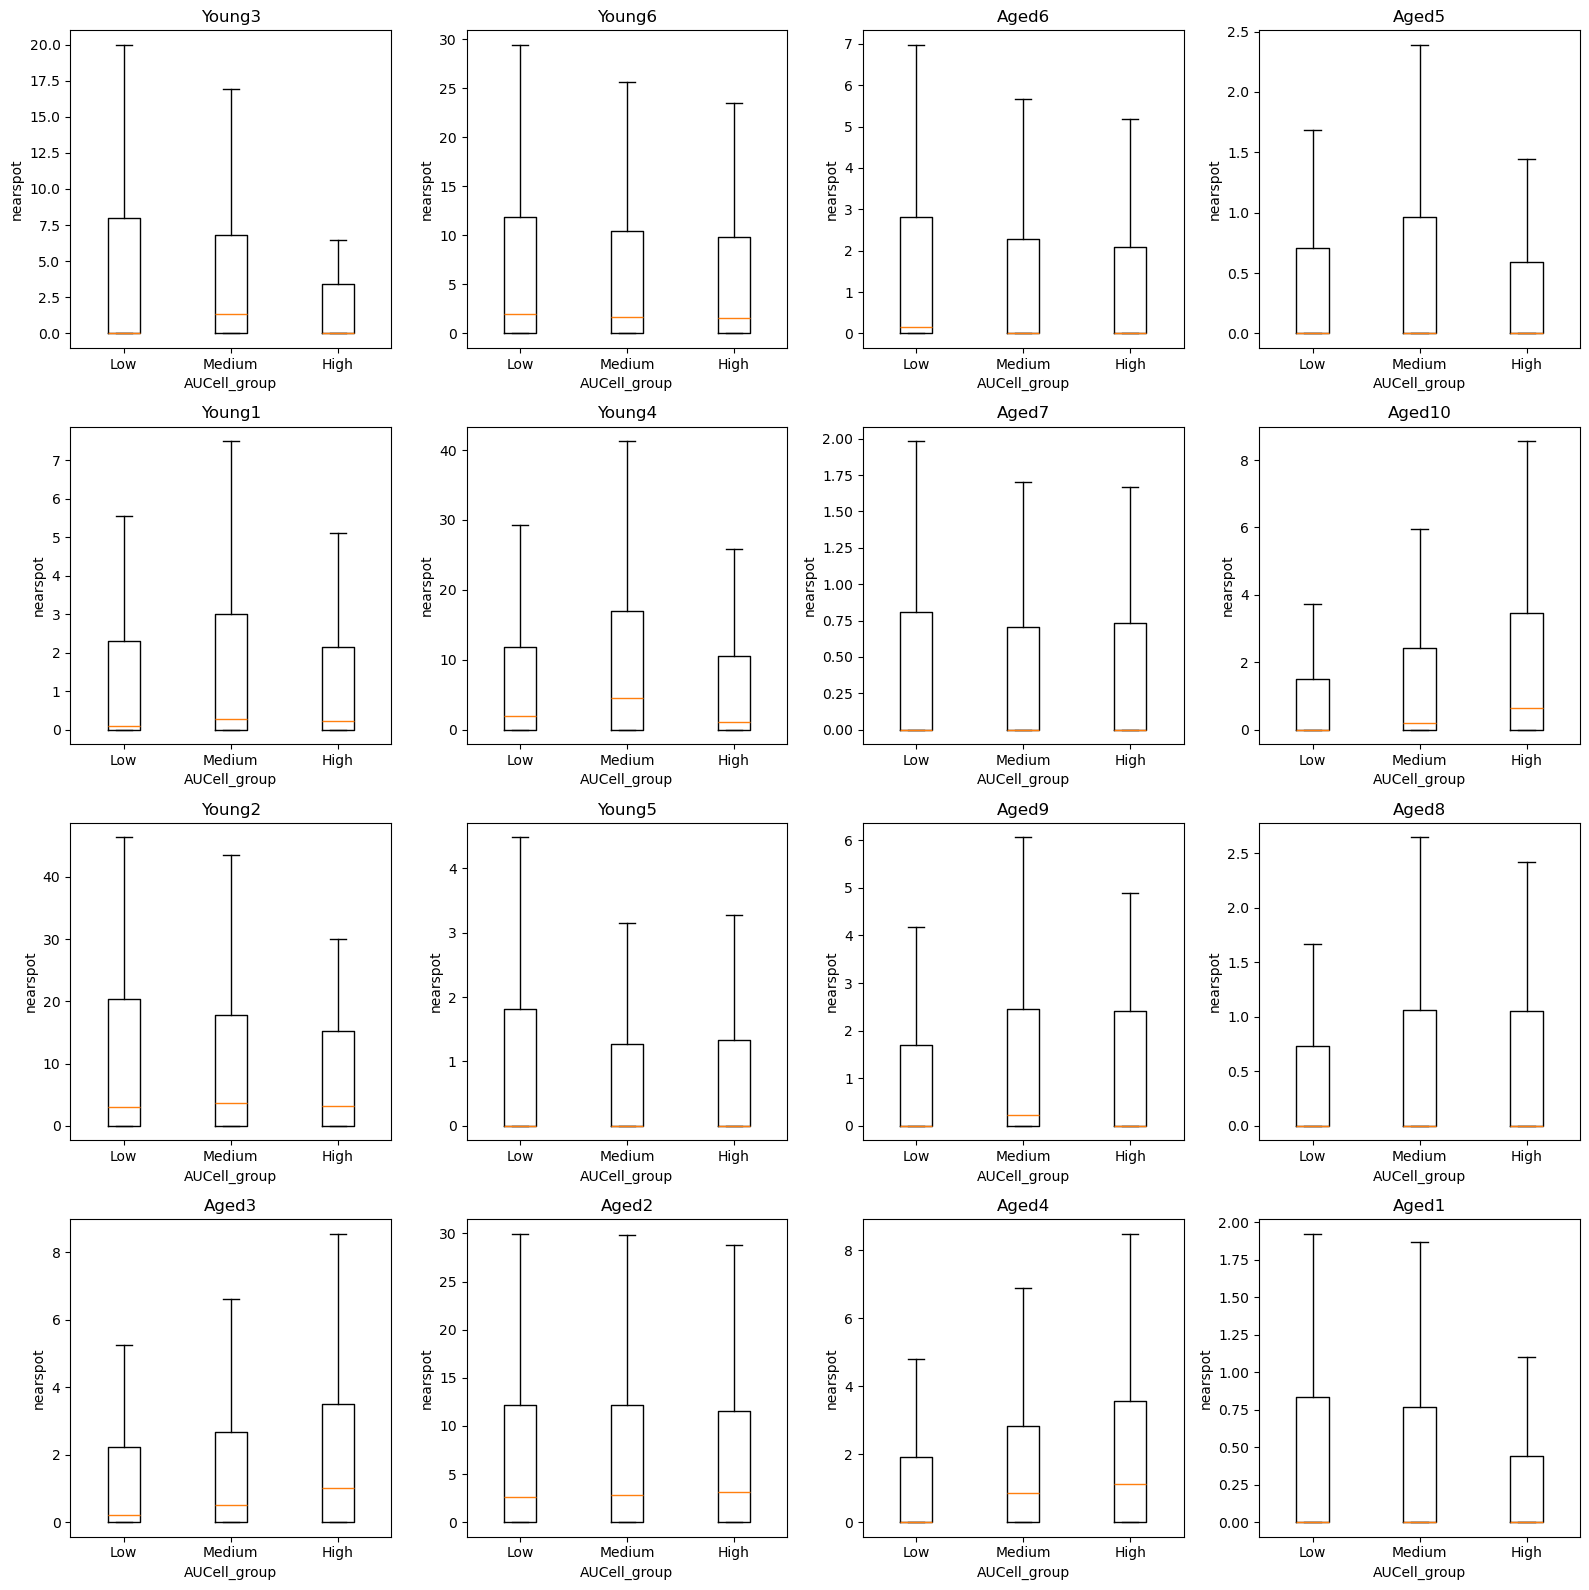

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import math

groups = adata_vis.obs["group"].unique()
n = len(groups)

ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

order = ["Low", "Medium", "High"]

for ax, g in zip(axes, groups):

    sub = adata_vis.obs.loc[
        (adata_vis.obs["group"] == g) &
        (adata_vis.obs["AUCell_group"].isin(order))
    ]

    data = [
        sub.loc[sub["AUCell_group"] == k, "nearspot"].dropna().values
        for k in order
    ]

    ax.boxplot(
        data,
        labels=order,
        showfliers=False
    )

    ax.set_title(g)
    ax.set_xlabel("AUCell_group")
    ax.set_ylabel("nearspot")

for ax in axes[len(groups):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [113]:
## Each sample box plot

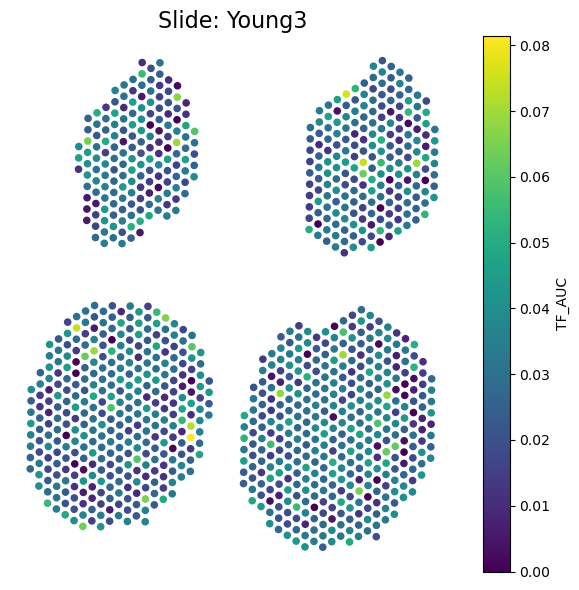

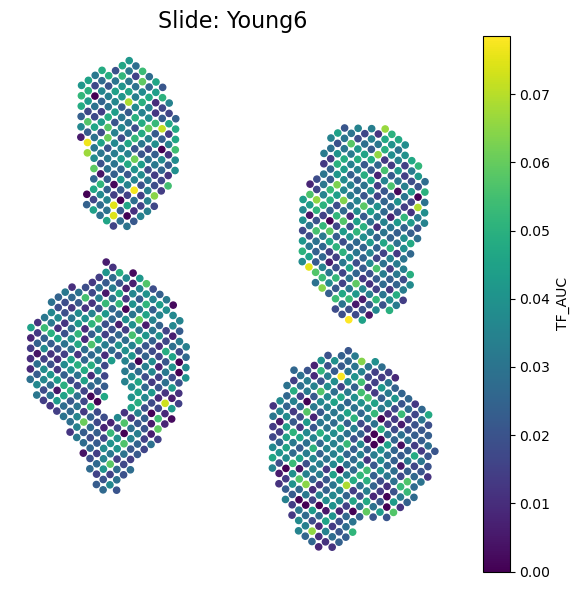

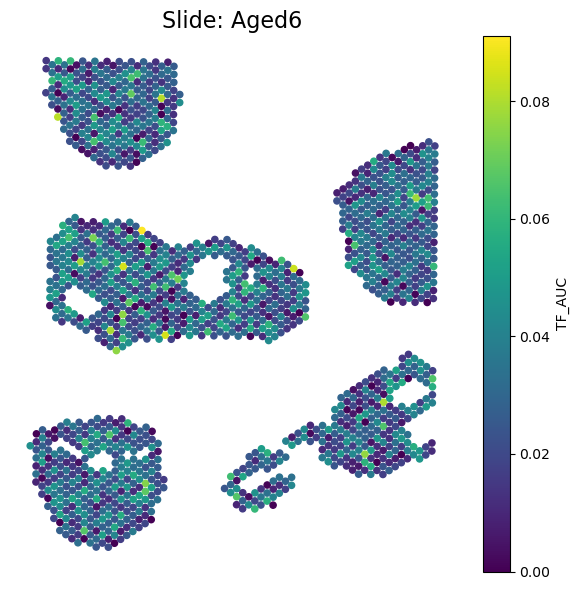

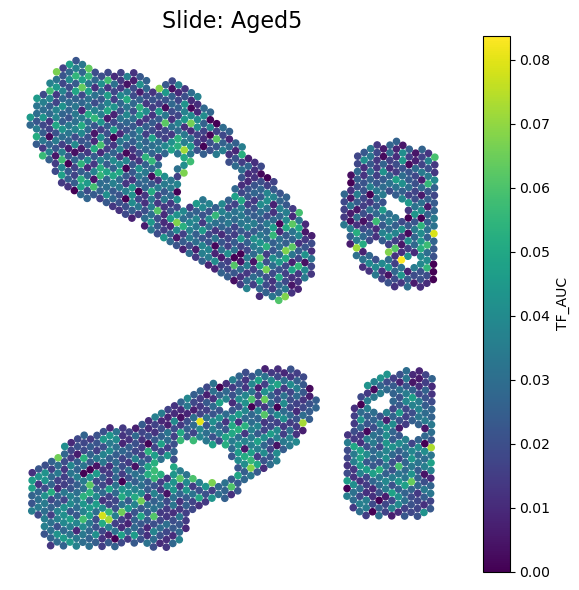

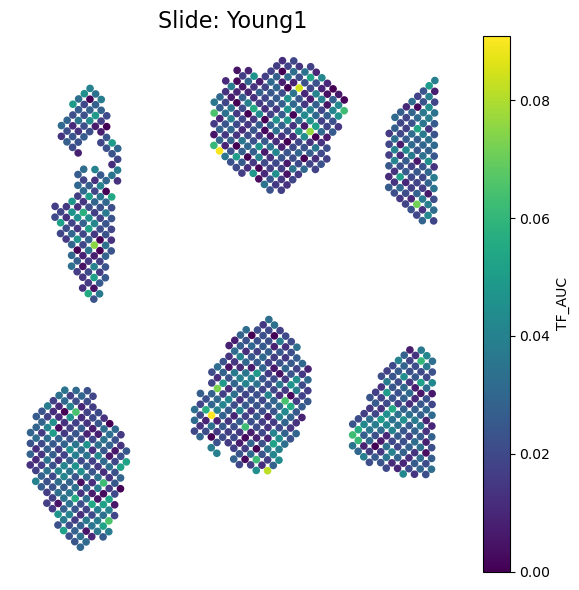

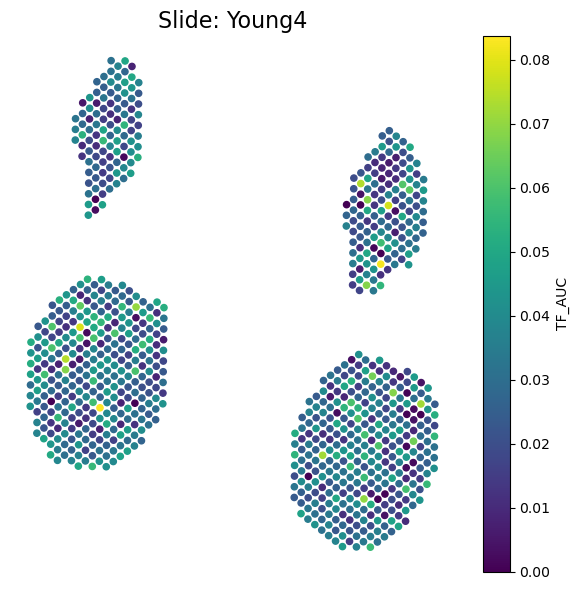

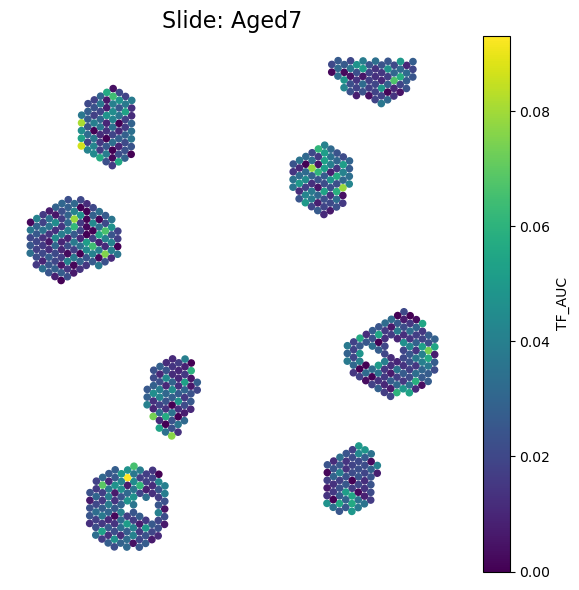

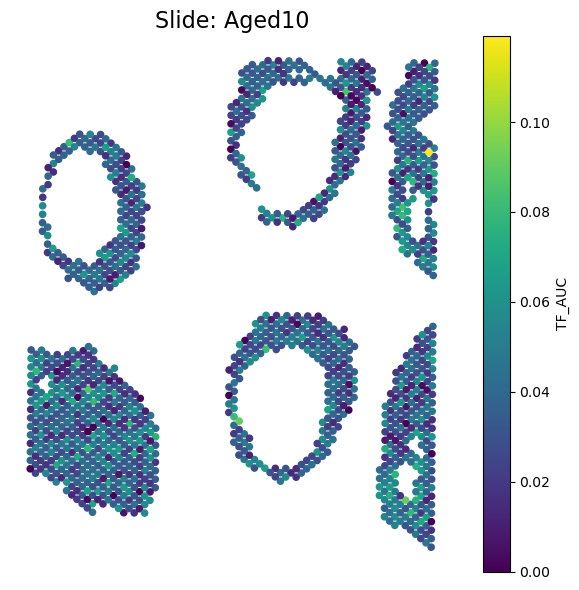

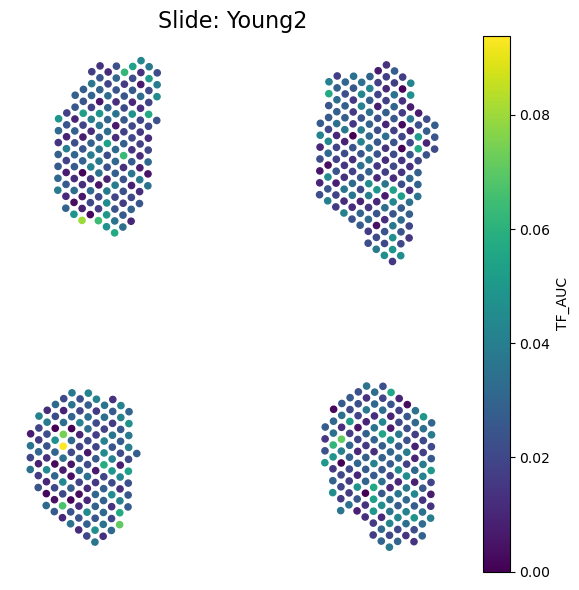

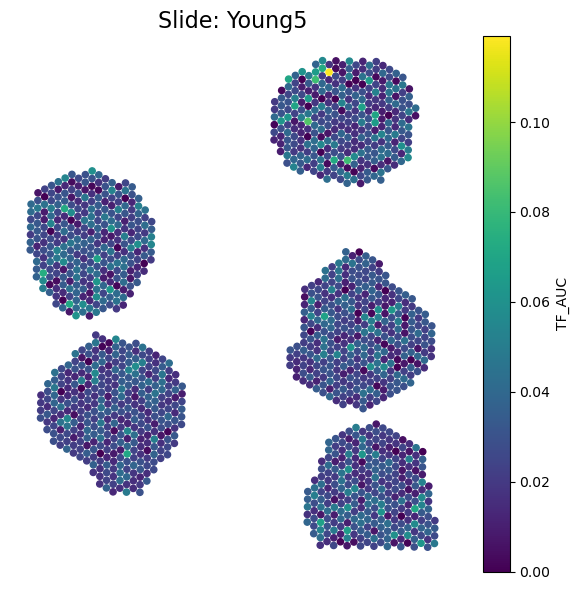

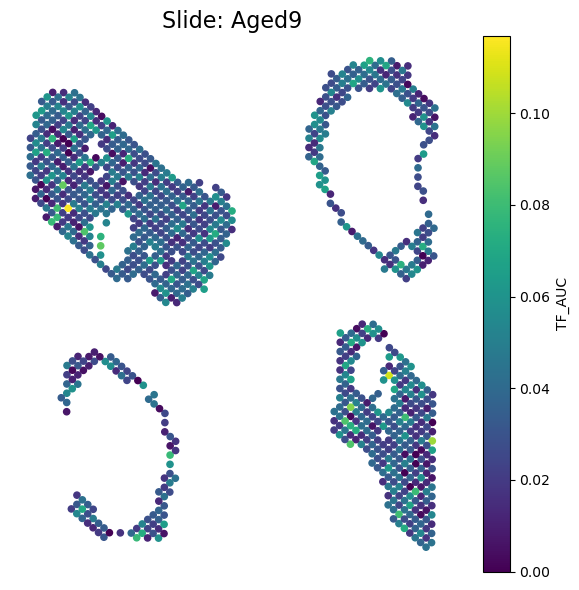

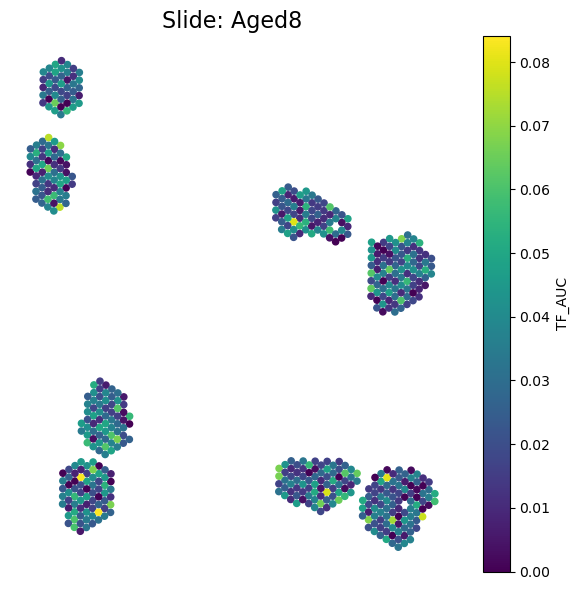

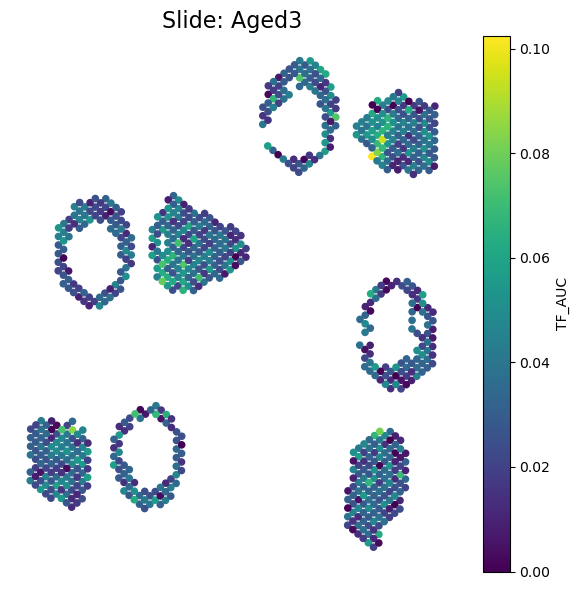

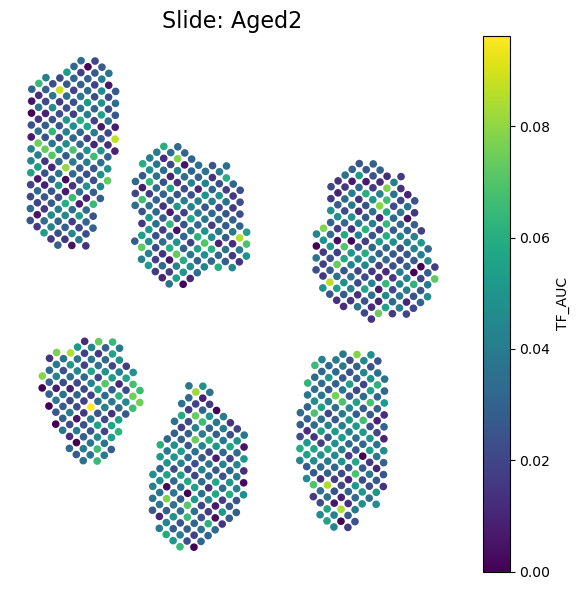

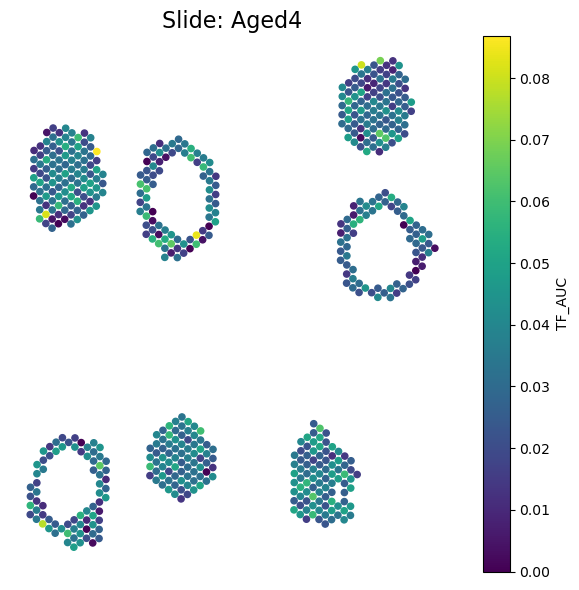

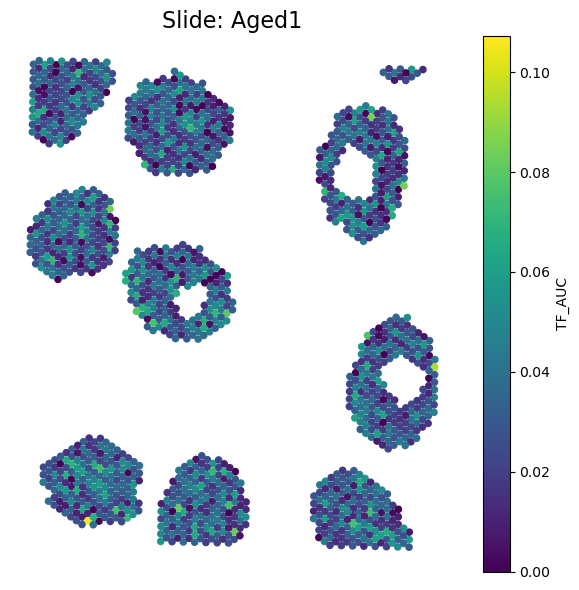

In [110]:
import matplotlib.pyplot as plt
import numpy as np

groups = adata_vis.obs["group"].unique().tolist()

for g in groups:
    ad = adata_vis[adata_vis.obs["group"] == g]

    coords = ad.obsm["spatial"]
    tf_auc = ad.obs["TF_AUC"].values

    plt.figure(figsize=(6, 6))

    sc = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=tf_auc,
        cmap="viridis",
        s=20
    )

    plt.title(f"Slide: {g}", fontsize=16)
    plt.axis("off")
    plt.colorbar(sc, label="TF_AUC")
    plt.tight_layout()
    plt.show()

<Figure size 1000x500 with 0 Axes>

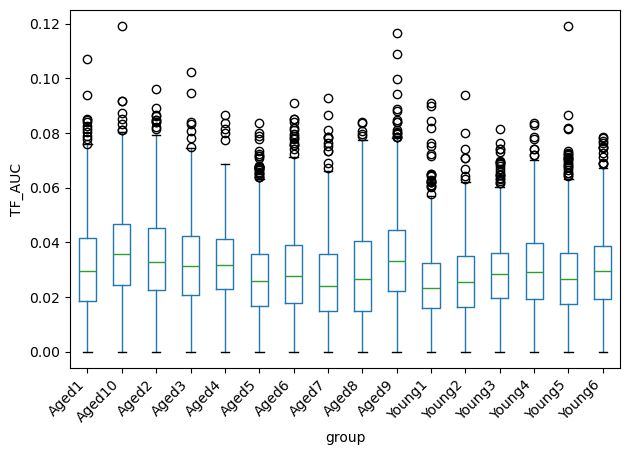

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

df = adata_vis.obs[["group", "TF_AUC"]].dropna()

order = sorted(df["group"].unique())
df["group"] = pd.Categorical(df["group"], categories=order, ordered=True)

plt.figure(figsize=(0.5 * len(order) + 2, 5))
df.boxplot(column="TF_AUC", by="group", grid=False)
plt.title("")
plt.suptitle("")
plt.xlabel("group")
plt.ylabel("TF_AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [133]:
## Merge sample box plot

In [127]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

adata_vis = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad")
adata_vis.layers['counts'] = adata_vis.X
sc.pp.normalize_total(adata_vis, inplace=True)
sc.pp.log1p(adata_vis)

geneset = ['Tgfb1', 'Acvr1', 'Rhoa', 'Smurf2', 'Smurf1', 'Hipk2', 'Tgfbr1', 'Ppp1ca', 'Cdk9', 'Ski', 'Rab31', 'Apc', 'Bmp2', 'Ncor2', 'Id1', 'Id3', 'Id2', 'Bmpr1a', 'Bcar3', 'Bmpr2', 'Serpine1', 'N/A', 'Ppp1r15a', 'Arid4b', 'Cdh1', 'Map3k7', 'Skil', 'Sptbn1', 'Smad3', 'Wwtr1', 'Tgif1', 'Lefty1', 'Nog', 'Ifngr2', 'Smad1', 'Klf10', 'Smad7', 'Smad6', 'Ppm1a', 'Fkbp1a', 'Tjp1', 'Xiap', 'Eng', 'Trim33', 'Cdkn1c', 'Hdac1', 'Furin', 'Ctnnb1', 'Slc20a1', 'Thbs1', 'Ltbp2', 'Fnta', 'Pmepa1', 'Junb']
sc.tl.score_genes(adata_vis, geneset , score_name='tgfb',use_raw=False)

In [128]:
import glob

auc_dir = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/AUCell/merged/"
csv_files = glob.glob(f"{auc_dir}/all_cells_all_genesets_AUC_transposed.csv")

auc_list = []

for f in csv_files:
    df = pd.read_csv(f, index_col=0)
    auc_list.append(df)

auc_all = pd.concat(auc_list, axis=0)

tf_auc = auc_all.loc[
    auc_all.index.intersection(adata_vis.obs.index),
    "TF"]

adata_vis.obs["TF_AUC"] = tf_auc.reindex(adata_vis.obs.index)

<Figure size 1000x500 with 0 Axes>

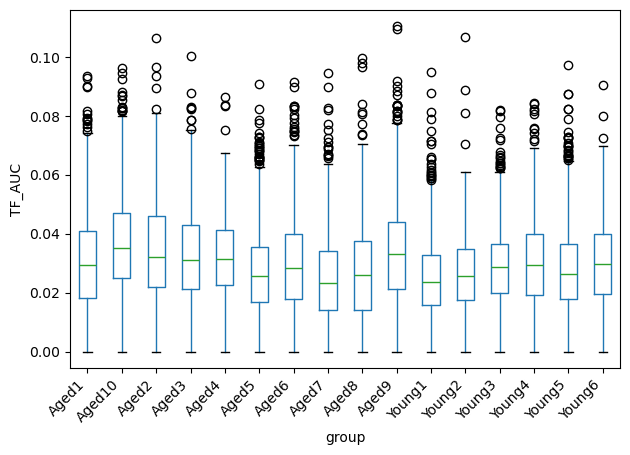

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

df = adata_vis.obs[["group", "TF_AUC"]].dropna()

order = sorted(df["group"].unique())
df["group"] = pd.Categorical(df["group"], categories=order, ordered=True)

plt.figure(figsize=(0.5 * len(order) + 2, 5))
df.boxplot(column="TF_AUC", by="group", grid=False)
plt.title("")
plt.suptitle("")
plt.xlabel("group")
plt.ylabel("TF_AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Figure size 400x500 with 0 Axes>

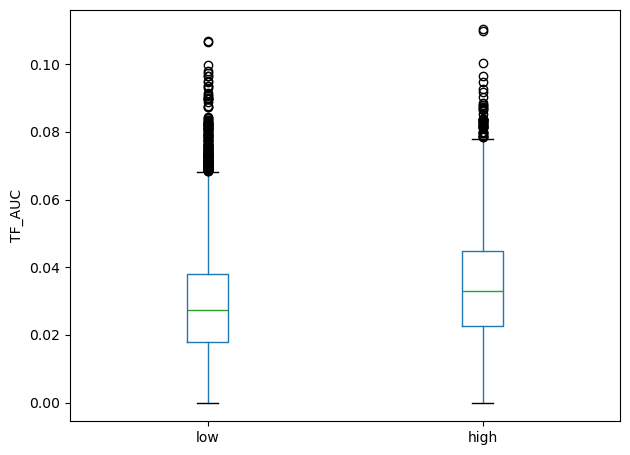

In [131]:
import pandas as pd
import matplotlib.pyplot as plt

high_groups = {"Aged4", "Aged3", "Aged9", "Aged10"}

df = adata_vis.obs[["group", "TF_AUC"]].dropna()
df["HL"] = df["group"].apply(lambda x: "high" if x in high_groups else "low")

df["HL"] = pd.Categorical(df["HL"], categories=["low", "high"], ordered=True)

plt.figure(figsize=(4, 5))
df.boxplot(column="TF_AUC", by="HL", grid=False)
plt.title("")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("TF_AUC")
plt.tight_layout()
plt.show()


# Predict

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

adata_vis = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad")
adata_vis.layers['counts'] = adata_vis.X
sc.pp.normalize_total(adata_vis, inplace=True)
sc.pp.log1p(adata_vis)

geneset = ['Tgfb1', 'Acvr1', 'Rhoa', 'Smurf2', 'Smurf1', 'Hipk2', 'Tgfbr1', 'Ppp1ca', 'Cdk9', 'Ski', 'Rab31', 'Apc', 'Bmp2', 'Ncor2', 'Id1', 'Id3', 'Id2', 'Bmpr1a', 'Bcar3', 'Bmpr2', 'Serpine1', 'N/A', 'Ppp1r15a', 'Arid4b', 'Cdh1', 'Map3k7', 'Skil', 'Sptbn1', 'Smad3', 'Wwtr1', 'Tgif1', 'Lefty1', 'Nog', 'Ifngr2', 'Smad1', 'Klf10', 'Smad7', 'Smad6', 'Ppm1a', 'Fkbp1a', 'Tjp1', 'Xiap', 'Eng', 'Trim33', 'Cdkn1c', 'Hdac1', 'Furin', 'Ctnnb1', 'Slc20a1', 'Thbs1', 'Ltbp2', 'Fnta', 'Pmepa1', 'Junb']
sc.tl.score_genes(adata_vis, geneset , score_name='tgfb',use_raw=False)

In [2]:
import glob

auc_dir = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/AUCell"
csv_files = glob.glob(f"{auc_dir}/*_all_cells_all_genesets_AUC_transposed.csv")

auc_list = []

for f in csv_files:
    df = pd.read_csv(f, index_col=0)
    auc_list.append(df)

auc_all = pd.concat(auc_list, axis=0)

tf_auc = auc_all.loc[
    auc_all.index.intersection(adata_vis.obs.index),
    "TF"]

adata_vis.obs["TF_AUC"] = tf_auc.reindex(adata_vis.obs.index)

In [3]:
adata_vis = adata_vis[adata_vis.obs['CD8_T_cells'] > 2.00].copy()

/tmp/ipykernel_3028195/1098116731.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipykernel_3028195/1098116731.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipykernel_3028195/1098116731.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipykernel_3028195/1098116731.py:16: FutureWarning: The default of observed=False is deprecated and

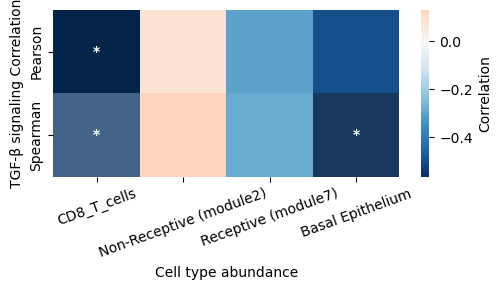

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

features = ["CD8_T_cells", "module2", "module7", "module8"]

df = adata_vis.obs[["group", "TF_AUC"] + features].dropna()

corr_vals = []
pval_vals = []

for f in features:
    summary = (
        df.groupby("group")
        .agg(
            x_val=(f, "median"),
            y_val=("TF_AUC", "median")
        )
    )

    x = summary["x_val"].values
    y = summary["y_val"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    corr_vals.append([pearson_r, spearman_r])
    pval_vals.append([pearson_p, spearman_p])

corr_df = pd.DataFrame(
    np.array(corr_vals).T,
    index=["Pearson", "Spearman"],
    columns=features
)

pval_df = pd.DataFrame(
    np.array(pval_vals).T,
    index=["Pearson", "Spearman"],
    columns=features
)

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

annot = pval_df.applymap(p_to_star)

plt.figure(figsize=(1.3 * len(features), 3))

ax = sns.heatmap(
    corr_df,
    cmap="RdBu_r",
    center=0,
    annot=annot,
    fmt="",
    cbar_kws={"label": "Correlation"}
)

for t in ax.texts:
    if t.get_text() != "":
        t.set_fontweight("bold")

star_mask = annot == ""

sns.heatmap(
    corr_df,
    cmap="Greys",
    mask=star_mask,
    alpha=0.25,
    cbar=False
)

new_labels = []

for lab in ax.get_xticklabels():
    txt = lab.get_text()

    if txt == "module8":
        txt = "Basal Epithelium"
    elif txt == "module2":
        txt = "Non-Receptive (module2)"
    elif txt == "module7":
        txt = "Receptive (module7)"

    new_labels.append(txt)

ax.set_xticklabels(new_labels, rotation=20)

plt.xlabel("Cell type abundance")
plt.ylabel("TGF-β signaling Correlation")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3028195/2410352470.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")


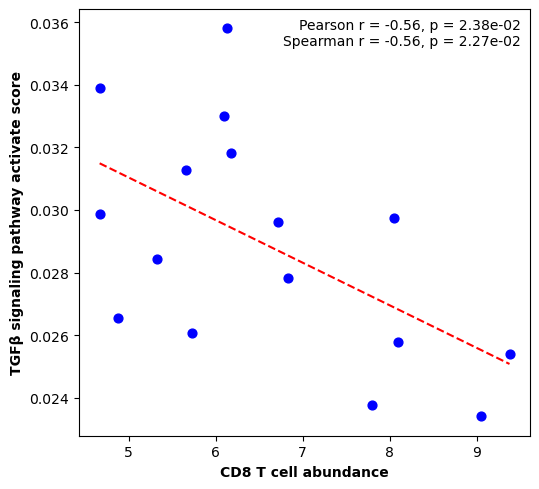

In [5]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt

high_groups = ["Young1", "Young2", "Young3", "Young4", "Young5", "Young6"]

summary_cd8 = (
    df.groupby("group")
      .agg(
          CD8_T_cells=("CD8_T_cells", "median"),
          TF_AUC=("TF_AUC", "median")
      )
      .reset_index()
)

summary_cd8["group_type"] = np.where(
    summary_cd8["group"].isin(high_groups),
    "High", "Low"
)

x = summary_cd8["CD8_T_cells"].values
y = summary_cd8["TF_AUC"].values

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

plt.figure(figsize=(5.5, 5))

plt.scatter(
    summary_cd8["CD8_T_cells"],
    summary_cd8["TF_AUC"],
    s=40,
    color="blue"
)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)
plt.plot(
    x_sorted,
    p(x_sorted),
    linestyle="--",
    color="red"
)

plt.xlabel(
    "CD8 T cell abundance",
    fontweight="bold"
)
plt.ylabel(
    "TGFβ signaling pathway activate score",
    fontweight="bold"
)

plt.text(
    0.98, 0.98,
    f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}\n"
    f"Spearman r = {spearman_r:.2f}, p = {spearman_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

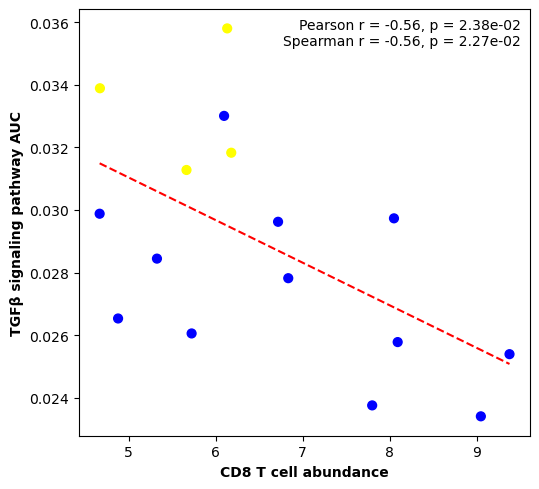

In [39]:
highlight_groups = ["Aged10", "Aged9", "Aged4", "Aged3"]

colors = ["yellow" if g in highlight_groups else "blue" for g in summary_cd8["group"]]

plt.figure(figsize=(5.5, 5))

plt.scatter(
    summary_cd8["CD8_T_cells"],
    summary_cd8["TF_AUC"],
    s=40,
    color=colors
)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)
plt.plot(
    x_sorted,
    p(x_sorted),
    linestyle="--",
    color="red"
)

plt.xlabel("CD8 T cell abundance", fontweight="bold")
plt.ylabel("TGFβ signaling pathway AUC", fontweight="bold")

plt.text(
    0.98, 0.98,
    f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}\n"
    f"Spearman r = {spearman_r:.2f}, p = {spearman_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10
)

plt.tight_layout()
plt.show()


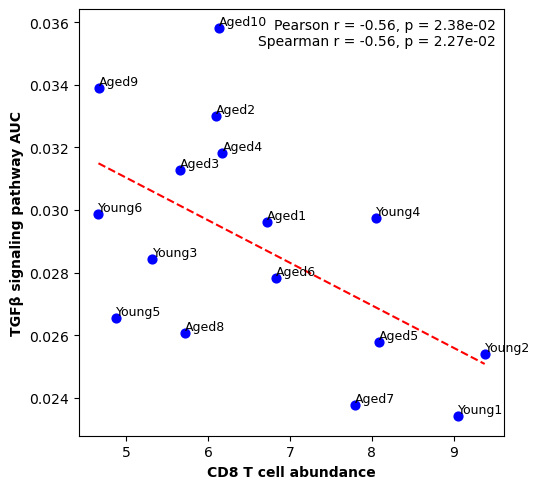

In [40]:
plt.figure(figsize=(5.5, 5))

plt.scatter(
    summary_cd8["CD8_T_cells"],
    summary_cd8["TF_AUC"],
    s=40,
    color="blue"
)

for _, r in summary_cd8.iterrows():
    plt.text(
        r["CD8_T_cells"],
        r["TF_AUC"],
        r["group"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)
plt.plot(
    x_sorted,
    p(x_sorted),
    linestyle="--",
    color="red"
)

plt.xlabel("CD8 T cell abundance", fontweight="bold")
plt.ylabel("TGFβ signaling pathway AUC", fontweight="bold")

plt.text(
    0.98, 0.98,
    f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}\n"
    f"Spearman r = {spearman_r:.2f}, p = {spearman_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Cell abundance

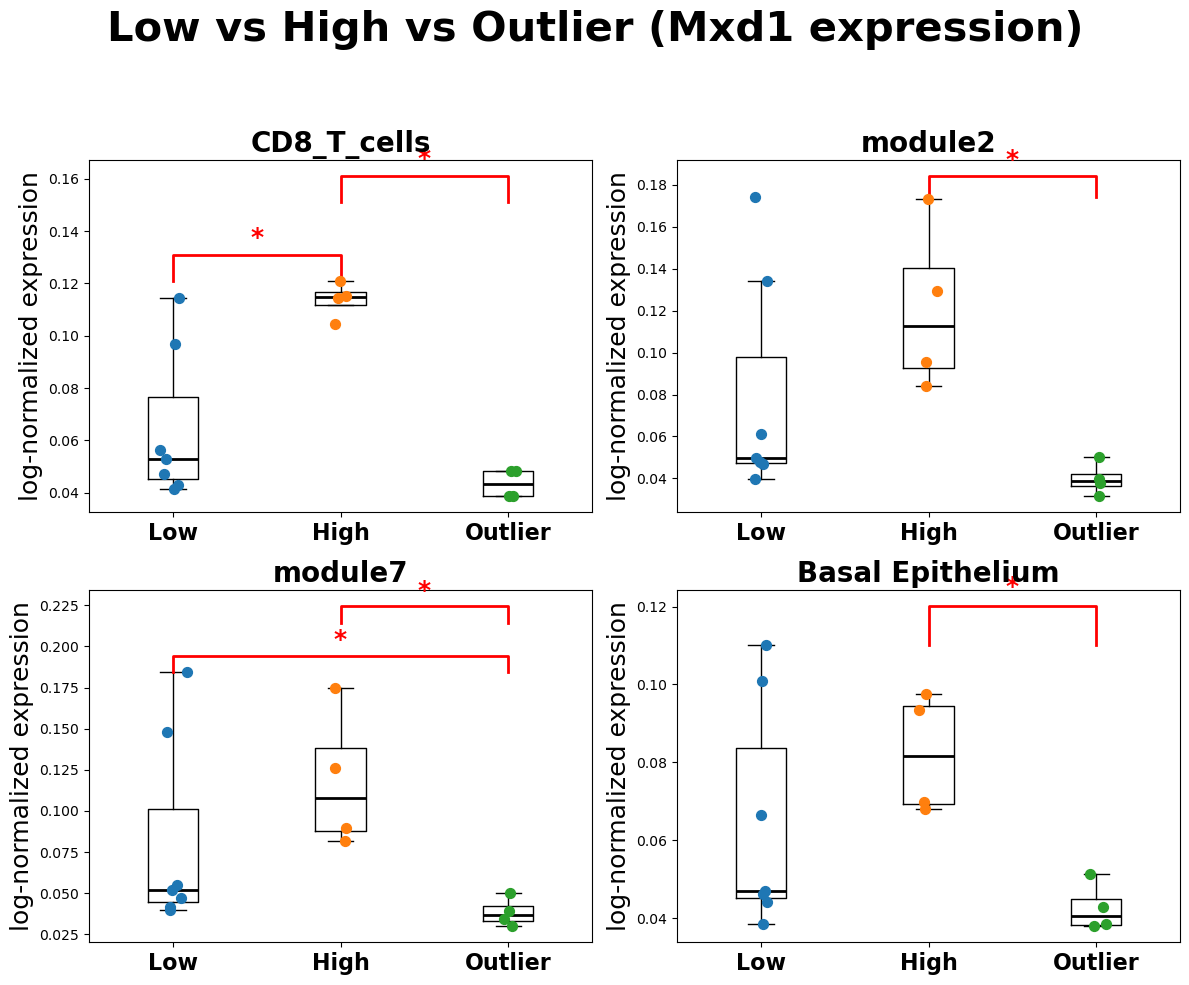

In [28]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

adata_vis = sc.read_h5ad(
    "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad"
)

group_high = ["Aged10", "Aged9", "Aged4", "Aged3"]
group_low = ["Aged2", "Young3", "Young5", "Aged5", "Aged6", "Young2", "Young4"]
group_outlier = ["Aged1", "Young1", "Aged8", "Aged7"]

adata_vis.obs["group_simple"] = np.select(
    [
        adata_vis.obs["group"].isin(group_high),
        adata_vis.obs["group"].isin(group_low),
        adata_vis.obs["group"].isin(group_outlier),
    ],
    ["high", "low", "outlier"],
    default=np.nan
)

adata_vis = adata_vis[~adata_vis.obs["group_simple"].isna()].copy()

sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)

factor_names = [
    "Basal Epithelium" if x == "module8" else x
    for x in adata_vis.uns["mod"]["factor_names"]
]

records = []

for sample_id in adata_vis.obs["sample_id"].unique():
    slide = adata_vis[adata_vis.obs["sample_id"] == sample_id]
    group_simple = slide.obs["group_simple"].iloc[0]
    abundance = slide.obsm["q05_cell_abundance_w_sf"]

    mxd1 = slide[:, "Mxd1"].X
    mxd1 = mxd1.toarray().flatten() if hasattr(mxd1, "toarray") else mxd1.flatten()

    for i, pop in enumerate(factor_names):
        w = abundance.iloc[:, i].values
        if w.sum() == 0:
            continue
        cutoff = np.quantile(w, 0.5)
        mask = w > cutoff
        if mask.sum() == 0:
            continue
        records.append({
            "sample_id": sample_id,
            "group": group_simple,
            "population": pop,
            "Mxd1_expr": np.average(mxd1[mask], weights=w[mask])
        })

df = pd.DataFrame(records)

n = len(factor_names)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
axes = axes.flatten()

rng = np.random.default_rng(42)

for ax, pop in zip(axes, factor_names):
    sub = df[df["population"] == pop]

    low = sub[sub["group"] == "low"]["Mxd1_expr"].values
    high = sub[sub["group"] == "high"]["Mxd1_expr"].values
    out = sub[sub["group"] == "outlier"]["Mxd1_expr"].values

    ax.boxplot(
        [low, high, out],
        showfliers=False,
        widths=0.3,
        medianprops=dict(color="black", linewidth=2)
    )

    x_low = 1 + rng.normal(0, 0.04, len(low))
    x_high = 2 + rng.normal(0, 0.04, len(high))
    x_out = 3 + rng.normal(0, 0.04, len(out))

    ax.scatter(x_low, low, s=50, zorder=3)
    ax.scatter(x_high, high, s=50, zorder=3)
    ax.scatter(x_out, out, s=50, zorder=3)

    pairs = [
        (low, high, 1, 2),
        (low, out, 1, 3),
        (high, out, 2, 3),
    ]

    y_base = max(
        np.max(low) if len(low) else -np.inf,
        np.max(high) if len(high) else -np.inf,
        np.max(out) if len(out) else -np.inf,
    )
    step = 0.03
    level = 0

    for a, b, x1, x2 in pairs:
        if len(a) > 0 and len(b) > 0:
            stat, p = mannwhitneyu(a, b, alternative="two-sided")
            if p < 0.05:
                if p < 0.001:
                    star = "***"
                elif p < 0.01:
                    star = "**"
                else:
                    star = "*"

                y = y_base + step * level
                h = 0.01

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + h, y + h, y],
                    color="red",
                    linewidth=2
                )
                ax.text(
                    (x1 + x2) / 2,
                    y + h + 0.002,
                    star,
                    ha="center",
                    va="bottom",
                    fontsize=18,
                    fontweight="bold",
                    color="red"
                )
                level += 1

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Low", "High", "Outlier"], fontsize=16, fontweight="bold")
    ax.set_ylabel("log-normalized expression", fontsize=18)
    ax.set_title(pop, fontsize=20, fontweight="bold")

for i in range(len(factor_names), len(axes)):
    axes[i].axis("off")

fig.suptitle(
    "Low vs High vs Outlier (Mxd1 expression)",
    fontsize=30,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

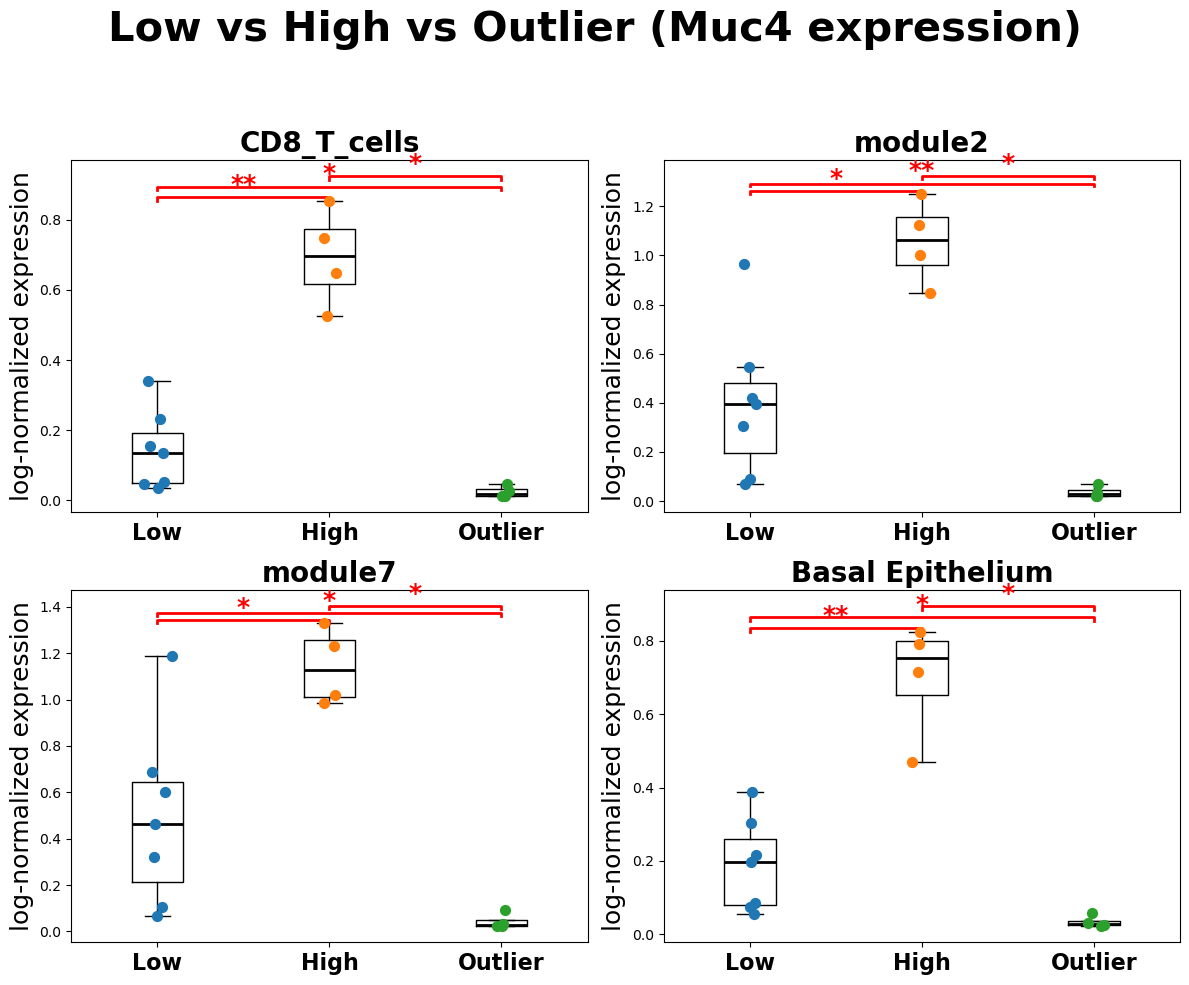

In [29]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

adata_vis = sc.read_h5ad(
    "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad"
)

group_high = ["Aged10", "Aged9", "Aged4", "Aged3"]
group_low = ["Aged2", "Young3", "Young5", "Aged5", "Aged6", "Young2", "Young4"]
group_outlier = ["Aged1", "Young1", "Aged8", "Aged7"]

adata_vis.obs["group_simple"] = np.select(
    [
        adata_vis.obs["group"].isin(group_high),
        adata_vis.obs["group"].isin(group_low),
        adata_vis.obs["group"].isin(group_outlier),
    ],
    ["high", "low", "outlier"],
    default=np.nan
)

adata_vis = adata_vis[~adata_vis.obs["group_simple"].isna()].copy()

sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)

factor_names = [
    "Basal Epithelium" if x == "module8" else x
    for x in adata_vis.uns["mod"]["factor_names"]
]

records = []

for sample_id in adata_vis.obs["sample_id"].unique():
    slide = adata_vis[adata_vis.obs["sample_id"] == sample_id]
    group_simple = slide.obs["group_simple"].iloc[0]
    abundance = slide.obsm["q05_cell_abundance_w_sf"]

    mxd1 = slide[:, "Muc4"].X
    mxd1 = mxd1.toarray().flatten() if hasattr(mxd1, "toarray") else mxd1.flatten()

    for i, pop in enumerate(factor_names):
        w = abundance.iloc[:, i].values
        if w.sum() == 0:
            continue
        cutoff = np.quantile(w, 0.5)
        mask = w > cutoff
        if mask.sum() == 0:
            continue
        records.append({
            "sample_id": sample_id,
            "group": group_simple,
            "population": pop,
            "Mxd1_expr": np.average(mxd1[mask], weights=w[mask])
        })

df = pd.DataFrame(records)

n = len(factor_names)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
axes = axes.flatten()

rng = np.random.default_rng(42)

for ax, pop in zip(axes, factor_names):
    sub = df[df["population"] == pop]

    low = sub[sub["group"] == "low"]["Mxd1_expr"].values
    high = sub[sub["group"] == "high"]["Mxd1_expr"].values
    out = sub[sub["group"] == "outlier"]["Mxd1_expr"].values

    ax.boxplot(
        [low, high, out],
        showfliers=False,
        widths=0.3,
        medianprops=dict(color="black", linewidth=2)
    )

    x_low = 1 + rng.normal(0, 0.04, len(low))
    x_high = 2 + rng.normal(0, 0.04, len(high))
    x_out = 3 + rng.normal(0, 0.04, len(out))

    ax.scatter(x_low, low, s=50, zorder=3)
    ax.scatter(x_high, high, s=50, zorder=3)
    ax.scatter(x_out, out, s=50, zorder=3)

    pairs = [
        (low, high, 1, 2),
        (low, out, 1, 3),
        (high, out, 2, 3),
    ]

    y_base = max(
        np.max(low) if len(low) else -np.inf,
        np.max(high) if len(high) else -np.inf,
        np.max(out) if len(out) else -np.inf,
    )
    step = 0.03
    level = 0

    for a, b, x1, x2 in pairs:
        if len(a) > 0 and len(b) > 0:
            stat, p = mannwhitneyu(a, b, alternative="two-sided")
            if p < 0.05:
                if p < 0.001:
                    star = "***"
                elif p < 0.01:
                    star = "**"
                else:
                    star = "*"

                y = y_base + step * level
                h = 0.01

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + h, y + h, y],
                    color="red",
                    linewidth=2
                )
                ax.text(
                    (x1 + x2) / 2,
                    y + h + 0.002,
                    star,
                    ha="center",
                    va="bottom",
                    fontsize=18,
                    fontweight="bold",
                    color="red"
                )
                level += 1

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Low", "High", "Outlier"], fontsize=16, fontweight="bold")
    ax.set_ylabel("log-normalized expression", fontsize=18)
    ax.set_title(pop, fontsize=20, fontweight="bold")

for i in range(len(factor_names), len(axes)):
    axes[i].axis("off")

fig.suptitle(
    "Low vs High vs Outlier (Muc4 expression)",
    fontsize=30,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

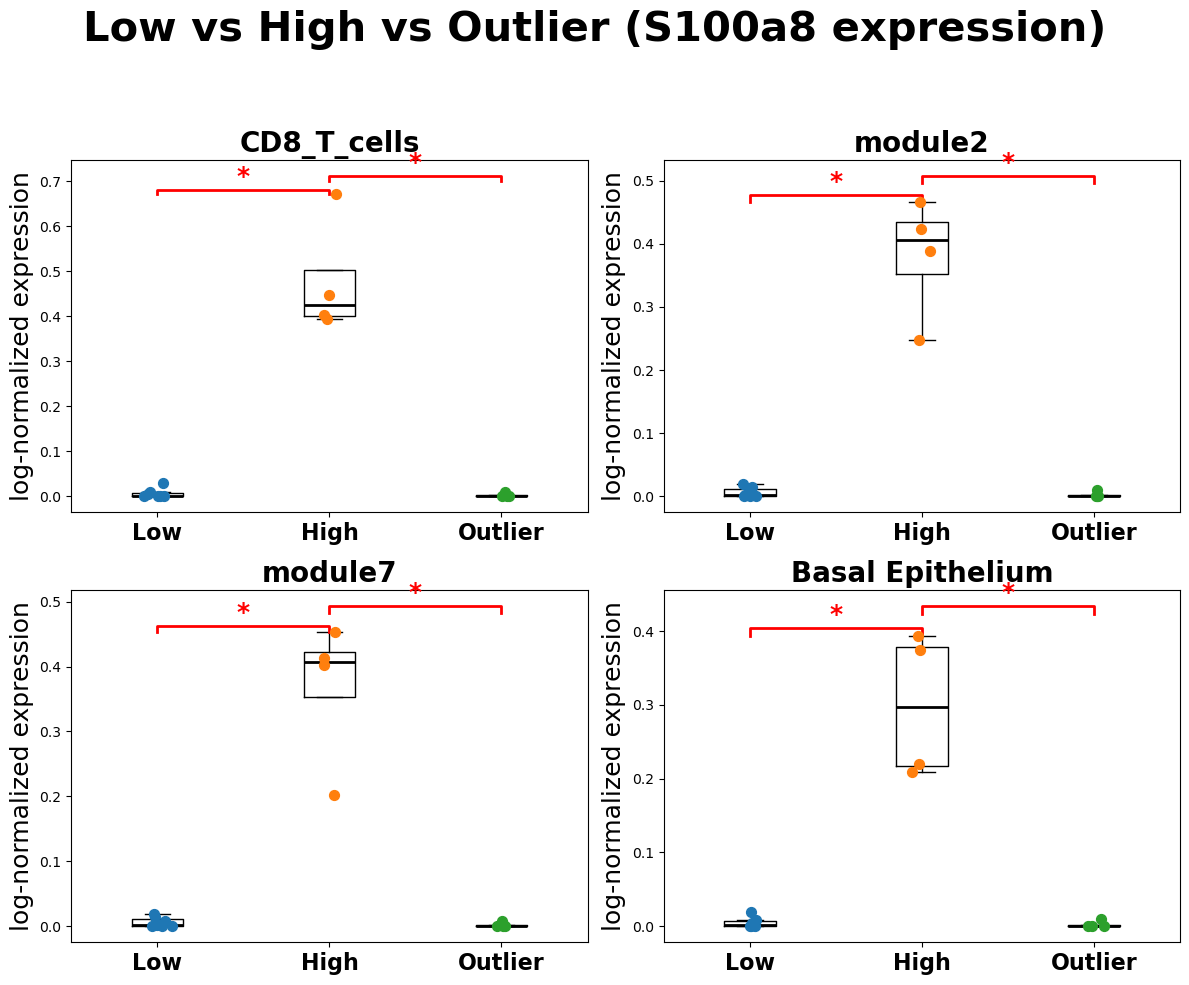

In [48]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

adata_vis = sc.read_h5ad(
    "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad"
)

group_high = ["Aged10", "Aged9", "Aged4", "Aged3"]
group_low = ["Aged2", "Young3", "Young5", "Aged5", "Aged6", "Young2", "Young4"]
group_outlier = ["Aged1", "Young1", "Aged8", "Aged7"]

adata_vis.obs["group_simple"] = np.select(
    [
        adata_vis.obs["group"].isin(group_high),
        adata_vis.obs["group"].isin(group_low),
        adata_vis.obs["group"].isin(group_outlier),
    ],
    ["high", "low", "outlier"],
    default=np.nan
)

adata_vis = adata_vis[~adata_vis.obs["group_simple"].isna()].copy()

sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)

factor_names = [
    "Basal Epithelium" if x == "module8" else x
    for x in adata_vis.uns["mod"]["factor_names"]
]

records = []

for sample_id in adata_vis.obs["sample_id"].unique():
    slide = adata_vis[adata_vis.obs["sample_id"] == sample_id]
    group_simple = slide.obs["group_simple"].iloc[0]
    abundance = slide.obsm["q05_cell_abundance_w_sf"]

    mxd1 = slide[:, "S100a8"].X
    mxd1 = mxd1.toarray().flatten() if hasattr(mxd1, "toarray") else mxd1.flatten()

    for i, pop in enumerate(factor_names):
        w = abundance.iloc[:, i].values
        if w.sum() == 0:
            continue
        cutoff = np.quantile(w, 0.5)
        mask = w > cutoff
        if mask.sum() == 0:
            continue
        records.append({
            "sample_id": sample_id,
            "group": group_simple,
            "population": pop,
            "Mxd1_expr": np.average(mxd1[mask], weights=w[mask])
        })

df = pd.DataFrame(records)

n = len(factor_names)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
axes = axes.flatten()

rng = np.random.default_rng(42)

for ax, pop in zip(axes, factor_names):
    sub = df[df["population"] == pop]

    low = sub[sub["group"] == "low"]["Mxd1_expr"].values
    high = sub[sub["group"] == "high"]["Mxd1_expr"].values
    out = sub[sub["group"] == "outlier"]["Mxd1_expr"].values

    ax.boxplot(
        [low, high, out],
        showfliers=False,
        widths=0.3,
        medianprops=dict(color="black", linewidth=2)
    )

    x_low = 1 + rng.normal(0, 0.04, len(low))
    x_high = 2 + rng.normal(0, 0.04, len(high))
    x_out = 3 + rng.normal(0, 0.04, len(out))

    ax.scatter(x_low, low, s=50, zorder=3)
    ax.scatter(x_high, high, s=50, zorder=3)
    ax.scatter(x_out, out, s=50, zorder=3)

    pairs = [
        (low, high, 1, 2),
        (low, out, 1, 3),
        (high, out, 2, 3),
    ]

    y_base = max(
        np.max(low) if len(low) else -np.inf,
        np.max(high) if len(high) else -np.inf,
        np.max(out) if len(out) else -np.inf,
    )
    step = 0.03
    level = 0

    for a, b, x1, x2 in pairs:
        if len(a) > 0 and len(b) > 0:
            stat, p = mannwhitneyu(a, b, alternative="two-sided")
            if p < 0.05:
                if p < 0.001:
                    star = "***"
                elif p < 0.01:
                    star = "**"
                else:
                    star = "*"

                y = y_base + step * level
                h = 0.01

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + h, y + h, y],
                    color="red",
                    linewidth=2
                )
                ax.text(
                    (x1 + x2) / 2,
                    y + h + 0.002,
                    star,
                    ha="center",
                    va="bottom",
                    fontsize=18,
                    fontweight="bold",
                    color="red"
                )
                level += 1

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Low", "High", "Outlier"], fontsize=16, fontweight="bold")
    ax.set_ylabel("log-normalized expression", fontsize=18)
    ax.set_title(pop, fontsize=20, fontweight="bold")

for i in range(len(factor_names), len(axes)):
    axes[i].axis("off")

fig.suptitle(
    "Low vs High vs Outlier (S100a8 expression)",
    fontsize=30,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

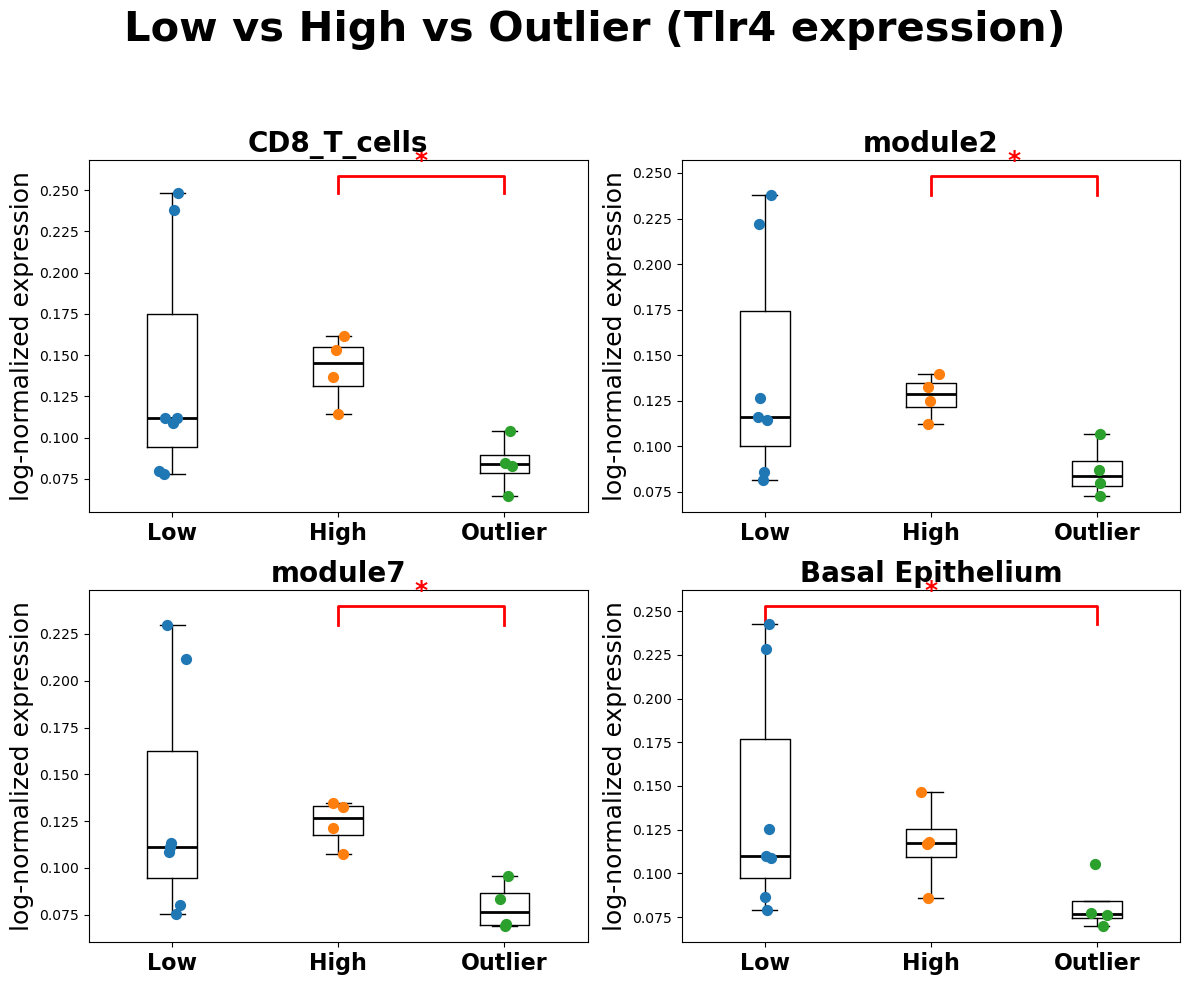

In [54]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

adata_vis = sc.read_h5ad(
    "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad"
)

group_high = ["Aged10", "Aged9", "Aged4", "Aged3"]
group_low = ["Aged2", "Young3", "Young5", "Aged5", "Aged6", "Young2", "Young4"]
group_outlier = ["Aged1", "Young1", "Aged8", "Aged7"]

adata_vis.obs["group_simple"] = np.select(
    [
        adata_vis.obs["group"].isin(group_high),
        adata_vis.obs["group"].isin(group_low),
        adata_vis.obs["group"].isin(group_outlier),
    ],
    ["high", "low", "outlier"],
    default=np.nan
)

adata_vis = adata_vis[~adata_vis.obs["group_simple"].isna()].copy()

sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)

factor_names = [
    "Basal Epithelium" if x == "module8" else x
    for x in adata_vis.uns["mod"]["factor_names"]
]

records = []

for sample_id in adata_vis.obs["sample_id"].unique():
    slide = adata_vis[adata_vis.obs["sample_id"] == sample_id]
    group_simple = slide.obs["group_simple"].iloc[0]
    abundance = slide.obsm["q05_cell_abundance_w_sf"]

    mxd1 = slide[:, "Tlr4"].X
    mxd1 = mxd1.toarray().flatten() if hasattr(mxd1, "toarray") else mxd1.flatten()

    for i, pop in enumerate(factor_names):
        w = abundance.iloc[:, i].values
        if w.sum() == 0:
            continue
        cutoff = np.quantile(w, 0.5)
        mask = w > cutoff
        if mask.sum() == 0:
            continue
        records.append({
            "sample_id": sample_id,
            "group": group_simple,
            "population": pop,
            "Mxd1_expr": np.average(mxd1[mask], weights=w[mask])
        })

df = pd.DataFrame(records)

n = len(factor_names)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
axes = axes.flatten()

rng = np.random.default_rng(42)

for ax, pop in zip(axes, factor_names):
    sub = df[df["population"] == pop]

    low = sub[sub["group"] == "low"]["Mxd1_expr"].values
    high = sub[sub["group"] == "high"]["Mxd1_expr"].values
    out = sub[sub["group"] == "outlier"]["Mxd1_expr"].values

    ax.boxplot(
        [low, high, out],
        showfliers=False,
        widths=0.3,
        medianprops=dict(color="black", linewidth=2)
    )

    x_low = 1 + rng.normal(0, 0.04, len(low))
    x_high = 2 + rng.normal(0, 0.04, len(high))
    x_out = 3 + rng.normal(0, 0.04, len(out))

    ax.scatter(x_low, low, s=50, zorder=3)
    ax.scatter(x_high, high, s=50, zorder=3)
    ax.scatter(x_out, out, s=50, zorder=3)

    pairs = [
        (low, high, 1, 2),
        (low, out, 1, 3),
        (high, out, 2, 3),
    ]

    y_base = max(
        np.max(low) if len(low) else -np.inf,
        np.max(high) if len(high) else -np.inf,
        np.max(out) if len(out) else -np.inf,
    )
    step = 0.03
    level = 0

    for a, b, x1, x2 in pairs:
        if len(a) > 0 and len(b) > 0:
            stat, p = mannwhitneyu(a, b, alternative="two-sided")
            if p < 0.05:
                if p < 0.001:
                    star = "***"
                elif p < 0.01:
                    star = "**"
                else:
                    star = "*"

                y = y_base + step * level
                h = 0.01

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + h, y + h, y],
                    color="red",
                    linewidth=2
                )
                ax.text(
                    (x1 + x2) / 2,
                    y + h + 0.002,
                    star,
                    ha="center",
                    va="bottom",
                    fontsize=18,
                    fontweight="bold",
                    color="red"
                )
                level += 1

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Low", "High", "Outlier"], fontsize=16, fontweight="bold")
    ax.set_ylabel("log-normalized expression", fontsize=18)
    ax.set_title(pop, fontsize=20, fontweight="bold")

for i in range(len(factor_names), len(axes)):
    axes[i].axis("off")

fig.suptitle(
    "Low vs High vs Outlier (Tlr4 expression)",
    fontsize=30,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Pathway

In [23]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

adata_vis = sc.read_h5ad(
    "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad"
)

group_high = ["Aged10", "Aged9", "Aged4", "Aged3"]
group_low = ["Aged6", "Aged5",
              "Aged2","Young6", "Young5", "Young4",
              "Young3", "Young2","Aged1", "Young1", "Aged8", "Aged7"]

adata_vis.obs["group_simple"] = np.select(
    [
        adata_vis.obs["group"].isin(group_high),
        adata_vis.obs["group"].isin(group_low),
        adata_vis.obs["group"].isin(group_outlier),
    ],
    ["high", "low", "outlier"],
    default=np.nan
)

adata_vis = adata_vis[~adata_vis.obs["group_simple"].isna()].copy()

sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)

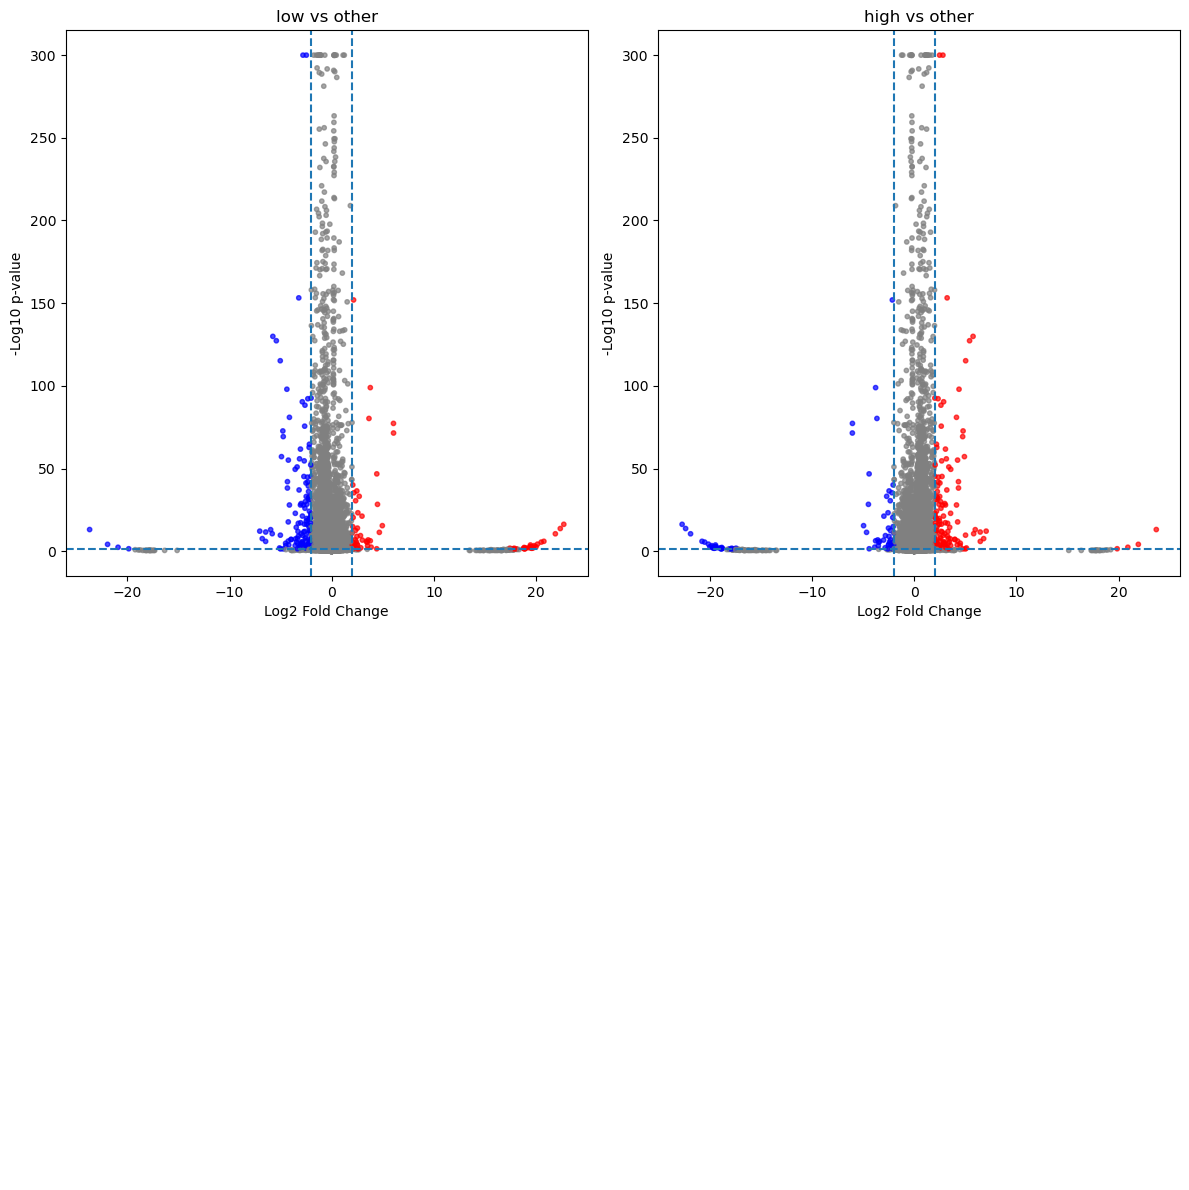

In [24]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

clusters = adata_vis.obs['group_simple'].unique()[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, target_cluster in zip(axes, clusters):
    adata_target = adata_vis[adata_vis.obs['group_simple'] == target_cluster]
    adata_other = adata_vis[adata_vis.obs['group_simple'] != target_cluster]

    X_target = adata_target.X.toarray() if hasattr(adata_target.X, "toarray") else adata_target.X
    X_other = adata_other.X.toarray() if hasattr(adata_other.X, "toarray") else adata_other.X

    mean_target = X_target.mean(axis=0)
    mean_other = X_other.mean(axis=0)

    lfc = np.log2(mean_target + 1e-9) - np.log2(mean_other + 1e-9)

    pvals = np.array([
        ttest_ind(X_target[:, i], X_other[:, i], equal_var=False).pvalue
        for i in range(adata_vis.n_vars)
    ])

    neglog10_pval = -np.log10(pvals + 1e-300)

    colors = np.full(adata_vis.n_vars, "grey", dtype=object)
    colors[(lfc > 2) & (pvals < 0.05)] = "red"
    colors[(lfc < -2) & (pvals < 0.05)] = "blue"

    ax.scatter(lfc, neglog10_pval, c=colors, alpha=0.7, s=10)
    ax.axhline(-np.log10(0.05), linestyle="--")
    ax.axvline(2, linestyle="--")
    ax.axvline(-2, linestyle="--")
    ax.set_title(f"{target_cluster} vs other")
    ax.set_xlabel("Log2 Fold Change")
    ax.set_ylabel("-Log10 p-value")

for ax in axes[len(clusters):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
sc.tl.rank_genes_groups(adata_vis, 'group_simple', method="wilcoxon",use_raw =False)
sc.tl.dendrogram(adata_vis, groupby='group_simple')
result = adata_vis.uns["rank_genes_groups"]
groups = result["names"].dtype.names
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

up_dict = {}
down_dict = {}

for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"
    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())
sc.tl.dendrogram(adata_vis, groupby='group_simple')
result = adata_vis.uns["rank_genes_groups"]
groups = result["names"].dtype.names
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

up_dict = {}
down_dict = {}

for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"
    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

from qed.data import readtxt, readseurat, readscanpy
from qed.data import get_enrichment_dataframes
from qed.data import merge_df
from qed.data import query
import inspect

class GeneSet:
    def __init__(self, genes, name, annot=None):
        self.genes = genes
        self.name = name
        self.params = {}
        self.GO = []
        self.annot = annot or {}
dblist = [
    'KEGG_2021_Human',
    'Reactome_2022', 'Mouse_Gene_Atlas',
    'MSigDB_Hallmark_2020',
    'GO_Biological_Process_2023',
    'WikiPathway_2024_Human','WikiPathways_2024_Mouse','KEGG_2019_Mouse']

df_merge_up_100 = df_merge_up.head(20)
df_merge_up_100.to_csv('breast_cancer_DEG_up_leiden.csv', index=False, header=True)
alist = pd.read_csv('breast_cancer_DEG_up_leiden.csv')
geneset_list = []
for col in alist.columns:
    genes = alist[col].dropna().tolist()
    gs = GeneSet(genes=genes, name=col, annot={"Leiden": col})
    geneset_list.append(gs)
aalist = get_enrichment_dataframes(
    geneset_list=geneset_list,
    dblist=dblist,
    annot_colname="Leiden",
    n_jobs=None,
    handle_error=True,
    max_iter=1
)
df = merge_df(aalist)
df['Term'] = df['Term'].str.split(r'\(GO:').str[0].str.strip()
df['Term'] = df['Term'].str.split('R-H').str[0].str.strip()
df['Term'] = df['Term'].str.split('WP').str[0].str.strip()

from typing import List, Tuple, Dict
def heatmap_with_groupwise_ordering(df: pd.DataFrame,
                                     n: int,
                                     group_by: str,
                                     order_by: str = "Adjusted p-value",
                                     cmap: str = 'Blues',
                                     xlabel_rotation: int = 90,
                                     xlabel_fontsize: int = 15,
                                     ylabel_fontsize: int = 15,
                                     figsize: Tuple = (15, 10),
                                     vmin: float = None,
                                     vmax: float = None,
                                     cbar_kws: Dict = None,
                                     linewidths: float = 0.1,
                                     title: str = None,
                                     save_to_file: str = None,
                                     enable_column_order: bool = False,
                                     column_order: list = None,
                                     enable_highlight_columns: bool = False,
                                     highlight_column_names: list = None):

    if not isinstance(df, pd.DataFrame):
        raise TypeError("입력 'df'는 pandas DataFrame이어야 합니다.")
    if group_by not in df.columns:
        raise ValueError(f"'{group_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if order_by not in df.columns:
        raise ValueError(f"'{order_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if 'Term' not in df.columns:
        raise ValueError("'Term' 컬럼이 DataFrame에 존재하지 않습니다.")

    has_overlapping_genes = 'Overlapping genes' in df.columns
    df_copy = df.copy()
    df_copy[order_by] = pd.to_numeric(df_copy[order_by], errors='coerce')
    df = df_copy

    df['Term_lower'] = df['Term'].str.lower()

    df_filtered_by_order = df[df[order_by].notna()]
    df_ranked_per_group = (
        df_filtered_by_order
        .sort_values(order_by)
        .groupby(group_by)
        .head(n)
        .reset_index(drop=True)
    )
    if df_ranked_per_group.empty:
        print(f"⚠️ 각 그룹에서 상위 {n}개의 Term을 선택할 수 없습니다.")
        return None, None

    all_selected_terms_lower = df_ranked_per_group['Term_lower'].unique()
    overlapping_genes_pivot = pd.DataFrame()
    if has_overlapping_genes:
        overlapping_genes_df = df[df['Term_lower'].isin(all_selected_terms_lower)][['Term_lower', group_by, 'Overlapping genes']]
        overlapping_genes_df['Overlapping genes'] = overlapping_genes_df['Overlapping genes'].apply(
            lambda x: ', '.join(map(str, x)) if isinstance(x, list) else str(x)
        )
        overlapping_genes_df = overlapping_genes_df.groupby(['Term_lower', group_by])['Overlapping genes'].apply(', '.join).reset_index()
        overlapping_genes_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
        overlapping_genes_pivot = overlapping_genes_df.pivot(index='Term', columns=group_by, values='Overlapping genes').fillna('')
        overlapping_genes_pivot.index = overlapping_genes_pivot.index.map(lambda x: x.capitalize())
    aggregated_df = df[df['Term_lower'].isin(all_selected_terms_lower)].groupby(['Term_lower', group_by], as_index=False)[order_by].min()
    aggregated_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
    pivot_df = aggregated_df.pivot(index="Term", columns=group_by, values=order_by).fillna(1).rename_axis(None, axis=1)
    is_pvalue_column = order_by.lower() in ['adjusted p-value', 'p-value']
    pivot_df_for_heatmap = -np.log10(np.maximum(pivot_df, np.finfo(float).eps)) if is_pvalue_column else pivot_df.copy()
    pivot_df_for_heatmap.index = pivot_df_for_heatmap.index.map(lambda x: x.capitalize())
    final_pivot_df = pd.concat([pivot_df_for_heatmap, overlapping_genes_pivot], axis=1)

    if save_to_file:
        try:
            final_pivot_df.to_csv(save_to_file, encoding='utf-8-sig')
            print(f"✅ 히트맵 데이터 저장 완료: '{save_to_file}'")
        except Exception as e:
            print(f"❌ 저장 실패: {e}")

    row_order = []
    seen_terms = set()

    if enable_column_order and column_order:
        group_order_for_plot = [group for group in column_order if group in df[group_by].unique()]
    else:
        group_order_for_plot = df[group_by].unique()

    for group in group_order_for_plot:
        current_group_terms = df_ranked_per_group[df_ranked_per_group[group_by] == group].sort_values(order_by)
        for term_lower_val in current_group_terms['Term_lower']:
            capitalized_term = term_lower_val.capitalize()
            if capitalized_term in pivot_df_for_heatmap.index and capitalized_term not in seen_terms:
                row_order.append(capitalized_term)
                seen_terms.add(capitalized_term)

    clustered_data = final_pivot_df.loc[row_order]
    heatmap_data = clustered_data.select_dtypes(include=[np.number]) 
    if enable_column_order and column_order:
        valid_cols = [c for c in column_order if c in heatmap_data.columns]
        if valid_cols:
            heatmap_data = heatmap_data[valid_cols]
    else:
        try:
        # 모든 열 이름을 float으로 바꿔 보고 성공하면 오름차순 재정렬
            numeric_col_keys = [float(c) for c in heatmap_data.columns]
            sorted_cols = [col for _, col in sorted(zip(numeric_col_keys, heatmap_data.columns))]
            heatmap_data = heatmap_data[sorted_cols]
        except ValueError:
            pass

    if is_pvalue_column:
        p_values_for_annotation = 10 ** (-np.clip(heatmap_data, None, 300))
        annotations = np.where(p_values_for_annotation <= 0.05, '*', '')
        annotations = annotations.astype(object)
    else:
        annotations = False

    highlight_column_indices = []
    if enable_highlight_columns and highlight_column_names:
        highlight_column_indices = [
            list(heatmap_data.columns).index(col)
            for col in highlight_column_names if col in heatmap_data.columns
        ]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=linewidths, annot=annotations, fmt='',
                linecolor='white', ax=ax, cbar_kws=cbar_kws, square=True,
                annot_kws={"size": 12, "color": "white", "weight": "bold"})

    for x in highlight_column_indices:
        ax.vlines(x + 1, *ax.get_ylim(), colors='black', linewidth=2)

    plt.xticks(rotation=xlabel_rotation, fontsize=xlabel_fontsize)
    plt.yticks(fontsize=ylabel_fontsize)
    if title:
        ax.set_title(title, fontsize=18, pad=20)
    plt.grid(False)

    if 'Term_lower' in df.columns:
        df.drop(columns='Term_lower', inplace=True)

    return fig, ax

Processing genesets: 13it [00:01, 13.39it/s]                      

Status code: 400
Response content: b'<!DOCTYPE html>\n<html lang="en">\n<head>\n\t<title>Enrichr</title>\n\t<meta http-equiv="Content-Type" content="text/html;charset=UTF-8">\n\t<meta name="author" content="Edward Y. Chen"/>\n\t<meta name="viewport" content="width=750">\n\t<link rel="shortcut icon" type="image/x-icon" href="favicon.ico"/>\n\t<link rel="icon" type="image/ico" href="favicon.ico"/>\n\t<link rel="stylesheet" type="text/css" href="css/reset-min.css"/>\n\t<link href=\'https://fonts.googleapis.com/css?family=Droid+Sans\' rel=\'stylesheet\' type=\'text/css\'/>\n\t<link rel="stylesheet" type="text/css" href="css/common.css"/>\n\t<link rel="stylesheet" type="text/css" href="css/login.css"/>\n</head>\n<body>\n\t<div id="logo">\n\t\t<a href="index.html"><img src="images/enrichr-icon.png"/><span>En</span><span class="red">rich</span><span>r</span></a>\n\t</div>\n\t<div class="clear"></div>\n\t<div id="content" class="beveled">\n\t\t<div class="title">Error</div>\n\t\t<div>\n\t\t\tF

Processing genesets: 16it [00:01, 10.35it/s]


Trying to re-request...
Error processing high for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
high with WikiPathway_2024_Human completed!
low with MSigDB_Hallmark_2020 completed!
Error processing low for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
low with WikiPathway_2024_Human completed!


In [35]:
terms_to_keep = [
    "Termination Of O-glycan Biosynthesis",
    "Regulation Of Intrinsic Apoptotic Signaling Pathway In Response To DNA Damage By P53 Class Mediator",
    "DNA Damage Response, Signal Transduction By P53 Class Mediator Resulting In Cell Cycle Arrest",
    "Mucosal Immune Response",
    "Negative Regulation Of Cell Adhesion Mediated By Integrin",
    "Positive Regulation Of Cellular Senescence",
    "Positive Regulation Of Toll-Like Receptor 4 Signaling Pathway",
    "Innate Immune Response In Mucosa",
    "Regulation Of Cellular Senescence",
    "TGF-beta Receptor Signaling Activates SMADs",
    "Cellular Response To Hormone Stimulus",
    "Positive Regulation Of Blood Circulation",
    "Positive Regulation Of Vasculogenesis",
    "Angiogenesis Involved In Wound Healing",
    "Endothelial Cell Proliferation",
    "Cellular Response To Steroid Hormone Stimulus",
    "Heterotypic Cell-Cell Adhesion",
    "Homotypic Cell-Cell Adhesion",
    "Positive Regulation Of Cell-Cell Adhesion",
    "Response To Steroid Hormone",
    "Regulation Of Cell-Cell Adhesion"
]

df = df[df['Term'].isin(terms_to_keep)]

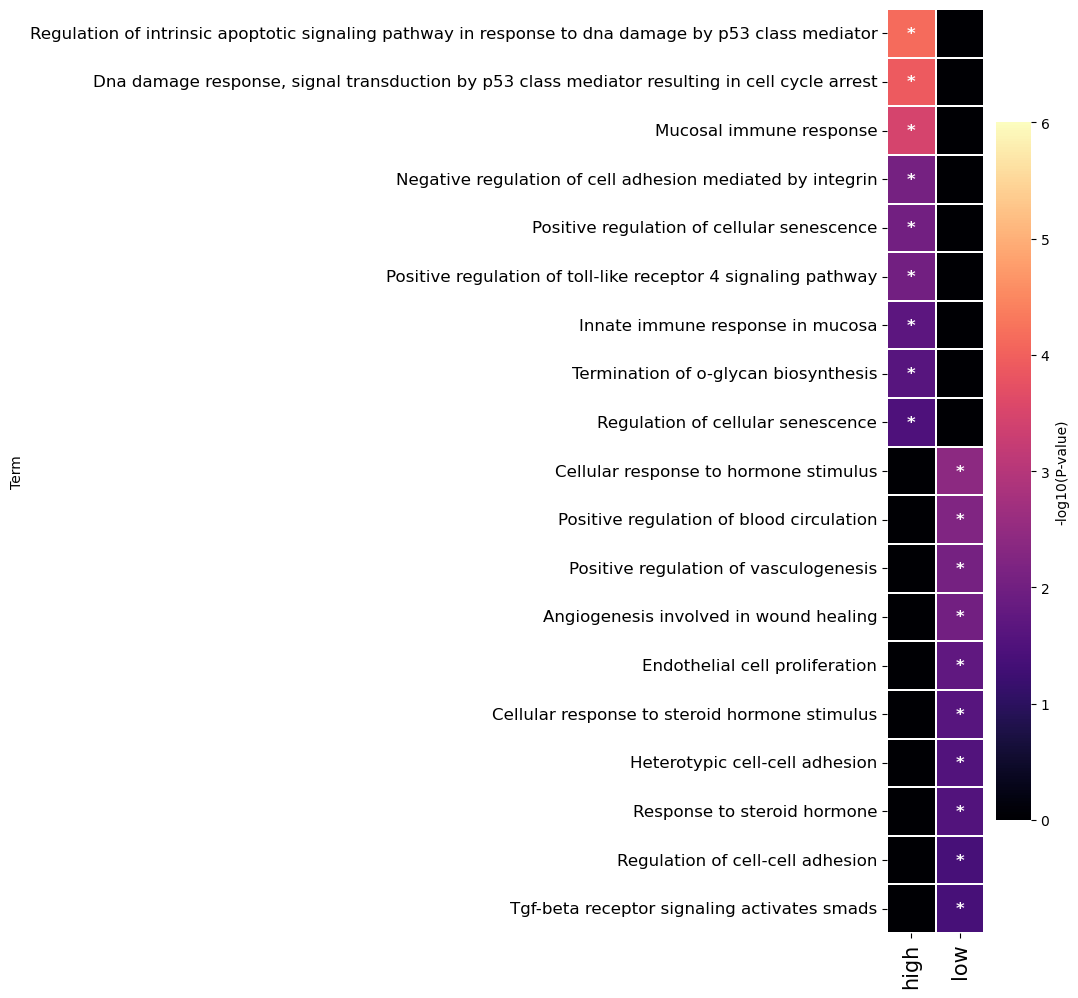

In [36]:
import seaborn as sns

fig, ax = heatmap_with_groupwise_ordering(
    df= df,
    n=10,
    group_by='Leiden',
    order_by="P-value",
    cmap='magma',
    xlabel_rotation=90,
    xlabel_fontsize=15,
    ylabel_fontsize=12,
    figsize=(3, 12),
    vmin=0, vmax=6,
    cbar_kws={'shrink': 1, 'label': '-log10(P-value)'},
    enable_column_order=False
)

In [33]:
import pandas as pd

df.to_csv("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/df.csv", index=False)